## Data Analysis

In [1]:
# Setup
import pandas as pd
import numpy as np
import csv
import os
import warnings
warnings.filterwarnings('ignore')
!pip install xlrd

RAW = 'data/raw'
 
PROC = 'data/processed'
os.makedirs(PROC, exist_ok=True)
 
print(f'Raw data folder:  {RAW}')
print(f'Output folder:    {PROC}')

Raw data folder:  data/raw
Output folder:    data/processed


In [2]:
# Helper functions
 
def parse_number(s):
    """Convert a string from Investing.com into a float."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip().replace('%', '').replace('K', '').replace('M', '').replace('B', '')
    if ',' in s and '.' in s:
        if s.index('.') < s.index(','):
            s = s.replace('.', '').replace(',', '.')  
        else:
            s = s.replace(',', '')                     
    elif ',' in s:
        parts = s.split(',')
        if len(parts) == 2 and len(parts[1]) == 3:
            s = s.replace(',', '')    
        else:
            s = s.replace(',', '.')   
    try:
        return float(s)
    except:
        return np.nan
 
 
def parse_date(s):
    """Convert a date string from Investing.com into a datetime object."""
    s = str(s).strip()
    if '/' in s:
        return pd.to_datetime(s, format='%m/%d/%Y')   
    else:
        return pd.to_datetime(s, format='%d.%m.%Y')   
 
 
print('Helper functions loaded.')

Helper functions loaded.


In [3]:
# LOAD ASSET PRICES (Gold & Bitcoin in USD)
 
# Bitcoin
btc_raw = pd.read_csv(os.path.join(RAW, 'BTC_USD.csv'), skiprows=1)
btc = pd.DataFrame()
btc['date'] = btc_raw['Date'].apply(parse_date)
btc['btc_price_usd'] = btc_raw['Price'].apply(parse_number)
btc = btc.sort_values('date').reset_index(drop=True)
 
# Gold
gold_raw = pd.read_csv(os.path.join(RAW, 'XAU_USD.csv'), skiprows=1)
gold = pd.DataFrame()
gold['date'] = gold_raw['Datum'].apply(parse_date)
gold['gold_price_usd'] = gold_raw['Zuletzt'].apply(parse_number)
gold = gold.sort_values('date').reset_index(drop=True)
 
# Merge into one table
assets = gold.merge(btc, on='date', how='outer').sort_values('date').reset_index(drop=True)
 
# Align all dates to end-of-month
assets['date'] = assets['date'].dt.to_period('M').dt.to_timestamp('M')
 
print(f'Assets: {assets["date"].min():%Y-%m} to {assets["date"].max():%Y-%m} ({len(assets)} months)')
assets.head()

Assets: 2016-01 to 2026-01 (121 months)


,date,gold_price_usd,btc_price_usd
0,2016-01-31,1117.64,365.5
1,2016-02-29,1237.76,439.2
2,2016-03-31,1231.95,416.0
3,2016-04-30,1293.36,446.6
4,2016-05-31,1214.69,530.7


In [4]:
# LOAD EXCHANGE RATES
 
# USD/CHF
raw = pd.read_csv(os.path.join(RAW, 'USD_CHF.csv'), skiprows=1)
usdchf = pd.DataFrame()
usdchf['date'] = raw['Datum'].apply(parse_date)
usdchf['usdchf'] = raw['Zuletzt'].apply(parse_number)
usdchf = usdchf.sort_values('date').reset_index(drop=True)
usdchf['date'] = usdchf['date'].dt.to_period('M').dt.to_timestamp('M')
 
# USD/JPY
raw = pd.read_csv(os.path.join(RAW, 'USD_JPY.csv'), skiprows=1)
usdjpy = pd.DataFrame()
usdjpy['date'] = raw['Datum'].apply(parse_date)
usdjpy['usdjpy'] = raw['Zuletzt'].apply(parse_number)
usdjpy = usdjpy.sort_values('date').reset_index(drop=True)
usdjpy['date'] = usdjpy['date'].dt.to_period('M').dt.to_timestamp('M')
 
# USD/ARS
raw = pd.read_csv(os.path.join(RAW, 'USD_ARS.csv'), skiprows=1)
usdars = pd.DataFrame()
usdars['date'] = raw['Date'].apply(parse_date)
usdars['usdars'] = raw['Price'].apply(parse_number)
usdars = usdars.sort_values('date').reset_index(drop=True)
usdars['date'] = usdars['date'].dt.to_period('M').dt.to_timestamp('M')
 
print(f'USD/CHF: {usdchf["date"].min():%Y-%m} to {usdchf["date"].max():%Y-%m}')
print(f'USD/JPY: {usdjpy["date"].min():%Y-%m} to {usdjpy["date"].max():%Y-%m}')
print(f'USD/ARS: {usdars["date"].min():%Y-%m} to {usdars["date"].max():%Y-%m}')

USD/CHF: 2016-01 to 2026-01
USD/JPY: 2016-01 to 2026-01
USD/ARS: 2016-01 to 2026-01


In [5]:
# CPI USA
 
cpi_us = pd.read_csv(os.path.join(RAW, 'CPI_USA.csv'), skiprows=1)
cpi_us.columns = ['date', 'cpi_index']
cpi_us['date'] = pd.to_datetime(cpi_us['date'])
cpi_us['date'] = cpi_us['date'].dt.to_period('M').dt.to_timestamp('M')
cpi_us = cpi_us.sort_values('date').reset_index(drop=True)
 
print(f'CPI USA: {cpi_us["date"].min():%Y-%m} to {cpi_us["date"].max():%Y-%m} ({len(cpi_us)} months)')
cpi_us.head()

CPI USA: 2015-01 to 2026-01 (133 months)


,date,cpi_index
0,2015-01-31,234.747
1,2015-02-28,235.342
2,2015-03-31,235.976
3,2015-04-30,236.222
4,2015-05-31,237.001


In [6]:
# CPI SWITZERLAND
 
cpi_ch = pd.read_csv(os.path.join(RAW, 'CPI_Switzerland.csv'), skiprows=4)
cpi_ch.columns = ['date', 'D0', 'cpi_index']
 
cpi_ch = cpi_ch[cpi_ch['D0'] == 'LD2010100'][['date', 'cpi_index']].copy()
cpi_ch['date'] = pd.to_datetime(cpi_ch['date'].str.strip(), format='%Y-%m')
cpi_ch['date'] = cpi_ch['date'].dt.to_period('M').dt.to_timestamp('M')
cpi_ch = cpi_ch.sort_values('date').reset_index(drop=True)
 
print(f'CPI CH: {cpi_ch["date"].min():%Y-%m} to {cpi_ch["date"].max():%Y-%m} ({len(cpi_ch)} months)')
cpi_ch.head()

CPI CH: 2015-01 to 2026-01 (133 months)


,date,cpi_index
0,2015-01-31,93.539359
1,2015-02-28,93.298940
2,2015-03-31,93.603321
3,2015-04-30,93.433410
4,2015-05-31,93.651012


In [7]:
# CPI JAPAN 

with open(os.path.join(RAW, 'CPI_Japan.csv'), 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    all_rows = list(reader)

jp_data = []
for row in all_rows:
    val = row[0].strip()
    if val.isdigit() and len(val) == 6 and int(val) >= 201500:
        jp_data.append({'date': val, 'cpi_index': float(row[1])})
 
cpi_jp = pd.DataFrame(jp_data)
cpi_jp['date'] = pd.to_datetime(cpi_jp['date'], format='%Y%m')
cpi_jp['date'] = cpi_jp['date'].dt.to_period('M').dt.to_timestamp('M')
cpi_jp = cpi_jp.sort_values('date').reset_index(drop=True)
 
print(f'CPI JP: {cpi_jp["date"].min():%Y-%m} to {cpi_jp["date"].max():%Y-%m} ({len(cpi_jp)} months)')
cpi_jp.head()

CPI JP: 2015-01 to 2026-01 (133 months)


,date,cpi_index
0,2015-01-31,97.8
1,2015-02-28,97.6
2,2015-03-31,97.9
3,2015-04-30,98.4
4,2015-05-31,98.7


In [8]:
# CPI ARGENTINA

# The INDEC index starts in Dec 2016, but I need data from Jan 2015 for YoY inflation.
# Solution: I use BCRA monthly rates to calculate the index backward to Jan 2015.
 
# Load BCRA monthly inflation rates
bcra = pd.read_excel(
    os.path.join(RAW, 'CPI_Argentina_Jan15-Dec16.xlsx'),
    sheet_name='Tabelle1', header=None, skiprows=4
)
bcra.columns = ['date', 'rate']
bcra['date'] = pd.to_datetime(bcra['date'])
bcra['rate'] = pd.to_numeric(bcra['rate'].astype(str).str.strip(), errors='coerce')
bcra['date'] = bcra['date'].dt.to_period('M').dt.to_timestamp('M')
bcra = bcra.sort_values('date').reset_index(drop=True)
 
print(f'BCRA monthly rates: {bcra["date"].min():%Y-%m} to {bcra["date"].max():%Y-%m}')
 
# Load INDEC CPI index
indec_raw = pd.read_excel(
    os.path.join(RAW, 'CPI_Argentina_Dec16_-_now.xls'),
    sheet_name='Índices IPC Cobertura Nacional',
    header=None
)

dates_row = indec_raw.iloc[5, 1:].values
values_row = indec_raw.iloc[9, 1:].values
 
indec = pd.DataFrame({'date': pd.to_datetime(dates_row),
                       'cpi_index': pd.to_numeric(values_row, errors='coerce')})
indec = indec.dropna()
indec['date'] = indec['date'].dt.to_period('M').dt.to_timestamp('M')
indec = indec.sort_values('date').reset_index(drop=True)
 
print(f'INDEC index: {indec["date"].min():%Y-%m} to {indec["date"].max():%Y-%m}')
 
# Reconstruct index backward from Dec 2016
rate_by_month = bcra.drop_duplicates(subset='date', keep='last').set_index('date')['rate']
 
reconstructed = {pd.Timestamp('2016-12-31'): 100.0}
current_value = 100.0
current_date = pd.Timestamp('2016-12-31')
 
while current_date > pd.Timestamp('2015-01-31'):
    if current_date in rate_by_month.index:
        r = rate_by_month[current_date]
        if pd.notna(r):
            current_value = current_value / (1 + r / 100)
    prev_date = current_date - pd.offsets.MonthEnd(1)
    reconstructed[prev_date] = current_value
    current_date = prev_date
 
backward = pd.DataFrame({'date': list(reconstructed.keys()),
                          'cpi_index': list(reconstructed.values())})
backward = backward.sort_values('date')
 
# Combine backward-reconstructed + INDEC forward
forward = indec[indec['date'] > pd.Timestamp('2016-12-31')].copy()
cpi_ar = pd.concat([backward, forward], ignore_index=True)
cpi_ar = cpi_ar.sort_values('date').drop_duplicates(subset='date', keep='last').reset_index(drop=True)
 
print(f'CPI AR (combined): {cpi_ar["date"].min():%Y-%m} to {cpi_ar["date"].max():%Y-%m} ({len(cpi_ar)} months)')
 
# Verify the junction point around Dec 2016
print('\nJunction check (smooth around Dec 2016):')
print(cpi_ar[cpi_ar['date'].between('2016-10-31', '2017-03-31')].to_string(index=False))

BCRA monthly rates: 2012-01 to 2025-12
INDEC index: 2016-12 to 2026-01
CPI AR (combined): 2015-01 to 2026-01 (133 months)

Junction check (smooth around Dec 2016):
      date  cpi_index
2016-10-31  97.258100
2016-11-30  98.814229
2016-12-31 100.000000
2017-01-31 101.585900
2017-02-28 103.685900
2017-03-31 106.147600


In [9]:
# POLICY RATE USA
 
rate_us = pd.read_csv(os.path.join(RAW, 'Policy_Rate_USA.csv'), skiprows=1)
rate_us.columns = ['date', 'policy_rate']
rate_us['date'] = pd.to_datetime(rate_us['date'])
rate_us['date'] = rate_us['date'].dt.to_period('M').dt.to_timestamp('M')
rate_us = rate_us.sort_values('date').reset_index(drop=True)
 
print(f'Rate US: {rate_us["date"].min():%Y-%m} to {rate_us["date"].max():%Y-%m}')

Rate US: 2016-01 to 2026-01


In [10]:
# POLICY RATE SWITZERLAND

# Before June 2019: No single rate – I use the midpoint of the Libor target band.
# From June 2019: SNB policy rate is used directly.
 
rate_ch_raw = pd.read_csv(os.path.join(RAW, 'Policy_Rate_Switzerland.csv'), skiprows=4)
rate_ch_raw.columns = ['date', 'D0', 'value']
 
lz = rate_ch_raw[rate_ch_raw['D0'] == 'LZ'][['date', 'value']].rename(columns={'value': 'lz'})
ug = rate_ch_raw[rate_ch_raw['D0'] == 'UG0'][['date', 'value']].rename(columns={'value': 'ug0'})
og = rate_ch_raw[rate_ch_raw['D0'] == 'OG0'][['date', 'value']].rename(columns={'value': 'og0'})
 
rate_ch = lz.merge(ug, on='date', how='outer').merge(og, on='date', how='outer')
 
rate_ch['policy_rate'] = rate_ch['lz']
missing = rate_ch['policy_rate'].isna()
rate_ch.loc[missing, 'policy_rate'] = (rate_ch.loc[missing, 'ug0'] + rate_ch.loc[missing, 'og0']) / 2
 
rate_ch = rate_ch[['date', 'policy_rate']].copy()
rate_ch['date'] = pd.to_datetime(rate_ch['date'].str.strip(), format='%Y-%m')
rate_ch['date'] = rate_ch['date'].dt.to_period('M').dt.to_timestamp('M')
rate_ch = rate_ch.sort_values('date').reset_index(drop=True)
 
print(f'Rate CH: {rate_ch["date"].min():%Y-%m} to {rate_ch["date"].max():%Y-%m}')
print('  Before June 2019: midpoint of Libor target band')
print('  From June 2019:   SNB policy rate')

Rate CH: 2016-01 to 2026-01
  Before June 2019: midpoint of Libor target band
  From June 2019:   SNB policy rate


In [11]:
# POLICY RATE JAPAN
 
rate_jp = pd.read_csv(os.path.join(RAW, 'Policy_Rate_Japan.csv'), skiprows=4)
rate_jp.columns = ['date', 'D0', 'policy_rate']
rate_jp = rate_jp[rate_jp['D0'] == 'L1'][['date', 'policy_rate']].copy()
rate_jp['date'] = pd.to_datetime(rate_jp['date'].str.strip(), format='%Y-%m')
rate_jp['policy_rate'] = pd.to_numeric(rate_jp['policy_rate'], errors='coerce')
rate_jp['date'] = rate_jp['date'].dt.to_period('M').dt.to_timestamp('M')
rate_jp = rate_jp.sort_values('date').reset_index(drop=True)
 
print(f'Rate JP: {rate_jp["date"].min():%Y-%m} to {rate_jp["date"].max():%Y-%m}')

Rate JP: 2016-01 to 2026-01


In [12]:
# POLICY RATE ARGENTINA

# The raw data is at irregular frequency.
# Each entry is valid until the next one, so I forward-fill to get monthly values.

rate_ar_raw = pd.read_excel(
    os.path.join(RAW, 'Policy_Rate_Argentina.xlsx'),
    sheet_name='Tasa_de_politica_monetaria (2)',
    header=None
)

rate_ar_data = rate_ar_raw.iloc[27:, [2, 3]].copy()
rate_ar_data.columns = ['date_raw', 'policy_rate']
rate_ar_data['date_raw'] = pd.to_numeric(rate_ar_data['date_raw'], errors='coerce')
rate_ar_data = rate_ar_data.dropna(subset=['date_raw'])
rate_ar_data['date'] = pd.to_datetime(rate_ar_data['date_raw'].astype(int).astype(str), format='%Y%m%d')
rate_ar_data['policy_rate'] = pd.to_numeric(rate_ar_data['policy_rate'], errors='coerce')

rate_ar_data = rate_ar_data.set_index('date').sort_index()
rate_ar = rate_ar_data[['policy_rate']].resample('ME').last()

full_range = pd.date_range(start=rate_ar.index.min(), end='2026-01-31', freq='ME')
rate_ar = rate_ar.reindex(full_range).ffill().dropna().reset_index()
rate_ar.columns = ['date', 'policy_rate']

print(f'Rate AR: {rate_ar["date"].min():%Y-%m} to {rate_ar["date"].max():%Y-%m} ({len(rate_ar)} months)')

Rate AR: 2015-12 to 2026-01 (122 months)


In [13]:
# MERGE DATA & COMPUTE VARIABLES

# For each country I compute:
# - Local currency prices (USD price × exchange rate)
# - Nominal monthly returns (% change in local currency price)
# - YoY inflation (12-month % change in CPI)
# - Monthly inflation (1-month % change in CPI)
# - Real monthly returns (nominal return minus monthly inflation)
# - Real interest rate proxy (policy rate / 12 minus monthly inflation)
#
# Analysis period: January 2016 to December 2025
 
START = '2016-01-31'
END = '2025-12-31'

In [14]:
# USA
df_us = assets.copy()
cpi_us_calc = cpi_us.copy()
cpi_us_calc['cpi_yoy'] = cpi_us_calc['cpi_index'].pct_change(12) * 100
cpi_us_calc['cpi_mom'] = cpi_us_calc['cpi_index'].pct_change() * 100
df_us = df_us.merge(cpi_us_calc, on='date', how='left')
df_us = df_us.merge(rate_us, on='date', how='left')
df_us['gold_price_local'] = df_us['gold_price_usd']
df_us['btc_price_local'] = df_us['btc_price_usd']
df_us['gold_ret'] = df_us['gold_price_local'].pct_change() * 100
df_us['btc_ret'] = df_us['btc_price_local'].pct_change() * 100
df_us['gold_real_ret'] = df_us['gold_ret'] - df_us['cpi_mom']
df_us['btc_real_ret'] = df_us['btc_ret'] - df_us['cpi_mom']
df_us['real_rate'] = df_us['policy_rate'] / 12 - df_us['cpi_mom']
df_us = df_us[(df_us['date'] >= START) & (df_us['date'] <= END)].copy()
print(f'USA: {len(df_us)} months, gold returns: {df_us["gold_ret"].notna().sum()}, CPI YoY: {df_us["cpi_yoy"].notna().sum()}')

USA: 120 months, gold returns: 119, CPI YoY: 120


In [15]:
# SWITZERLAND
df_ch = assets.copy()
cpi_ch_calc = cpi_ch.copy()
cpi_ch_calc['cpi_yoy'] = cpi_ch_calc['cpi_index'].pct_change(12) * 100
cpi_ch_calc['cpi_mom'] = cpi_ch_calc['cpi_index'].pct_change() * 100
df_ch = df_ch.merge(usdchf, on='date', how='left')
df_ch = df_ch.merge(cpi_ch_calc, on='date', how='left')
df_ch = df_ch.merge(rate_ch, on='date', how='left')
# Convert to CHF
df_ch['gold_price_local'] = df_ch['gold_price_usd'] * df_ch['usdchf']
df_ch['btc_price_local'] = df_ch['btc_price_usd'] * df_ch['usdchf']
df_ch['gold_ret'] = df_ch['gold_price_local'].pct_change() * 100
df_ch['btc_ret'] = df_ch['btc_price_local'].pct_change() * 100
df_ch['gold_real_ret'] = df_ch['gold_ret'] - df_ch['cpi_mom']
df_ch['btc_real_ret'] = df_ch['btc_ret'] - df_ch['cpi_mom']
df_ch['real_rate'] = df_ch['policy_rate'] / 12 - df_ch['cpi_mom']
df_ch = df_ch[(df_ch['date'] >= START) & (df_ch['date'] <= END)].copy()
print(f'Switzerland: {len(df_ch)} months, gold returns: {df_ch["gold_ret"].notna().sum()}, CPI YoY: {df_ch["cpi_yoy"].notna().sum()}')

Switzerland: 120 months, gold returns: 119, CPI YoY: 120


In [16]:
# JAPAN
df_jp = assets.copy()
cpi_jp_calc = cpi_jp.copy()
cpi_jp_calc['cpi_yoy'] = cpi_jp_calc['cpi_index'].pct_change(12) * 100
cpi_jp_calc['cpi_mom'] = cpi_jp_calc['cpi_index'].pct_change() * 100
df_jp = df_jp.merge(usdjpy, on='date', how='left')
df_jp = df_jp.merge(cpi_jp_calc, on='date', how='left')
df_jp = df_jp.merge(rate_jp, on='date', how='left')
# Convert to JPY
df_jp['gold_price_local'] = df_jp['gold_price_usd'] * df_jp['usdjpy']
df_jp['btc_price_local'] = df_jp['btc_price_usd'] * df_jp['usdjpy']
df_jp['gold_ret'] = df_jp['gold_price_local'].pct_change() * 100
df_jp['btc_ret'] = df_jp['btc_price_local'].pct_change() * 100
df_jp['gold_real_ret'] = df_jp['gold_ret'] - df_jp['cpi_mom']
df_jp['btc_real_ret'] = df_jp['btc_ret'] - df_jp['cpi_mom']
df_jp['real_rate'] = df_jp['policy_rate'] / 12 - df_jp['cpi_mom']
df_jp = df_jp[(df_jp['date'] >= START) & (df_jp['date'] <= END)].copy()
print(f'Japan: {len(df_jp)} months, gold returns: {df_jp["gold_ret"].notna().sum()}, CPI YoY: {df_jp["cpi_yoy"].notna().sum()}')

Japan: 120 months, gold returns: 119, CPI YoY: 120


In [17]:
# ARGENTINA
df_ar = assets.copy()
cpi_ar_calc = cpi_ar.copy()
cpi_ar_calc['cpi_yoy'] = cpi_ar_calc['cpi_index'].pct_change(12) * 100
cpi_ar_calc['cpi_mom'] = cpi_ar_calc['cpi_index'].pct_change() * 100
df_ar = df_ar.merge(usdars, on='date', how='left')
df_ar = df_ar.merge(cpi_ar_calc, on='date', how='left')
df_ar = df_ar.merge(rate_ar, on='date', how='left')
# Convert to ARS
df_ar['gold_price_local'] = df_ar['gold_price_usd'] * df_ar['usdars']
df_ar['btc_price_local'] = df_ar['btc_price_usd'] * df_ar['usdars']
df_ar['gold_ret'] = df_ar['gold_price_local'].pct_change() * 100
df_ar['btc_ret'] = df_ar['btc_price_local'].pct_change() * 100
df_ar['gold_real_ret'] = df_ar['gold_ret'] - df_ar['cpi_mom']
df_ar['btc_real_ret'] = df_ar['btc_ret'] - df_ar['cpi_mom']
df_ar['real_rate'] = df_ar['policy_rate'] / 12 - df_ar['cpi_mom']
df_ar = df_ar[(df_ar['date'] >= START) & (df_ar['date'] <= END)].copy()
print(f'Argentina: {len(df_ar)} months, gold returns: {df_ar["gold_ret"].notna().sum()}, CPI YoY: {df_ar["cpi_yoy"].notna().sum()}')

Argentina: 120 months, gold returns: 119, CPI YoY: 120


In [18]:
# SAVE PROCESSED DATASETS
df_us.to_csv(os.path.join(PROC, 'panel_usa.csv'), index=False)
df_ch.to_csv(os.path.join(PROC, 'panel_switzerland.csv'), index=False)
df_jp.to_csv(os.path.join(PROC, 'panel_japan.csv'), index=False)
df_ar.to_csv(os.path.join(PROC, 'panel_argentina.csv'), index=False)
 
print('Saved:')
print(f'  {PROC}/panel_usa.csv')
print(f'  {PROC}/panel_switzerland.csv')
print(f'  {PROC}/panel_japan.csv')
print(f'  {PROC}/panel_argentina.csv')

Saved:
  data/processed/panel_usa.csv
  data/processed/panel_switzerland.csv
  data/processed/panel_japan.csv
  data/processed/panel_argentina.csv


In [19]:
# VALIDATION
 
for name, df in [('USA', df_us), ('Switzerland', df_ch), ('Japan', df_jp), ('Argentina', df_ar)]:
    print(f'\n--- {name} ---')
    print(f'  Period:        {df["date"].min():%Y-%m} to {df["date"].max():%Y-%m} ({len(df)} months)')
    print(f'  CPI YoY:       {df["cpi_yoy"].min():.1f}% to {df["cpi_yoy"].max():.1f}%')
    print(f'  Gold nominal:  mean={df["gold_ret"].mean():.2f}%, std={df["gold_ret"].std():.2f}%')
    print(f'  BTC nominal:   mean={df["btc_ret"].mean():.2f}%, std={df["btc_ret"].std():.2f}%')
    print(f'  Gold real:     mean={df["gold_real_ret"].mean():.2f}%, std={df["gold_real_ret"].std():.2f}%')
    print(f'  BTC real:      mean={df["btc_real_ret"].mean():.2f}%, std={df["btc_real_ret"].std():.2f}%')
    print(f'  Policy rate:   {df["policy_rate"].min():.2f}% to {df["policy_rate"].max():.2f}%')


--- USA ---
  Period:        2016-01 to 2025-12 (120 months)
  CPI YoY:       0.2% to 9.0%
  Gold nominal:  mean=1.22%, std=4.06%
  BTC nominal:   mean=6.70%, std=20.86%
  Gold real:     mean=0.96%, std=4.10%
  BTC real:      mean=6.44%, std=20.89%
  Policy rate:   0.05% to 5.33%

--- Switzerland ---
  Period:        2016-01 to 2025-12 (120 months)
  CPI YoY:       -1.3% to 3.5%
  Gold nominal:  mean=0.98%, std=3.45%
  BTC nominal:   mean=6.49%, std=20.89%
  Gold real:     mean=0.92%, std=3.48%
  BTC real:      mean=6.43%, std=20.89%
  Policy rate:   -0.75% to 1.75%

--- Japan ---
  Period:        2016-01 to 2025-12 (120 months)
  CPI YoY:       -1.2% to 4.4%
  Gold nominal:  mean=1.42%, std=3.56%
  BTC nominal:   mean=6.93%, std=20.85%
  Gold real:     mean=1.30%, std=3.51%
  BTC real:      mean=6.80%, std=20.84%
  Policy rate:   -0.10% to 0.75%

--- Argentina ---
  Period:        2016-01 to 2025-12 (120 months)
  CPI YoY:       21.4% to 289.4%
  Gold nominal:  mean=5.78%, std=13.60%

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

GOLD_COLOR = '#DAA520'       # Gold
BTC_COLOR = '#1F77B4'        # Blue
INFLATION_COLOR = '#D62728'  # Red
RATE_COLOR = '#2CA02C'       # Green

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'figure.figsize': (12, 5),
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 2.0,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

FIGS = 'figures'
os.makedirs(FIGS, exist_ok=True)

print('Style configured.')

Style configured.


In [21]:
# SUMMARY STATISTICS (per country)

def summary_stats(df):
    cols = ['gold_ret', 'btc_ret', 'gold_real_ret', 'btc_real_ret', 'cpi_yoy', 'policy_rate']
    labels = ['Gold Nominal Return', 'Bitcoin Nominal Return', 'Gold Real Return',
              'Bitcoin Real Return', 'CPI YoY Inflation', 'Policy Rate']
    stats = []
    for col, label in zip(cols, labels):
        s = df[col].dropna()
        stats.append({
            'Variable': label,
            'Obs': int(s.count()),
            'Mean': round(s.mean(), 2),
            'Median': round(s.median(), 2),
            'Std Dev': round(s.std(), 2),
            'Min': round(s.min(), 2),
            'Max': round(s.max(), 2)
        })
    return pd.DataFrame(stats)

for name, df in [('USA', df_us), ('Switzerland', df_ch), ('Japan', df_jp), ('Argentina', df_ar)]:
    print(f'\n{"="*70}')
    print(f'  Summary Statistics: {name}')
    print(f'{"="*70}')
    print(summary_stats(df).to_string(index=False))


  Summary Statistics: USA
              Variable  Obs  Mean  Median  Std Dev    Min   Max
   Gold Nominal Return  119  1.22    0.48     4.06  -8.19 11.91
Bitcoin Nominal Return  119  6.70    2.83    20.86 -37.29 65.20
      Gold Real Return  119  0.96    0.30     4.10  -8.31 11.61
   Bitcoin Real Return  119  6.44    2.46    20.89 -38.54 64.82
     CPI YoY Inflation  120  3.14    2.54     2.09   0.20  8.98
           Policy Rate  120  2.19    1.69     1.91   0.05  5.33

  Summary Statistics: Switzerland
              Variable  Obs  Mean  Median  Std Dev    Min   Max
   Gold Nominal Return  119  0.98    0.31     3.45  -6.17 11.38
Bitcoin Nominal Return  119  6.49    2.98    20.89 -37.57 63.85
      Gold Real Return  119  0.92    0.18     3.48  -5.92 11.54
   Bitcoin Real Return  119  6.43    2.81    20.89 -38.07 63.82
     CPI YoY Inflation  120  0.75    0.63     1.12  -1.32  3.45
           Policy Rate  120 -0.17   -0.75     0.89  -0.75  1.75

  Summary Statistics: Japan
             

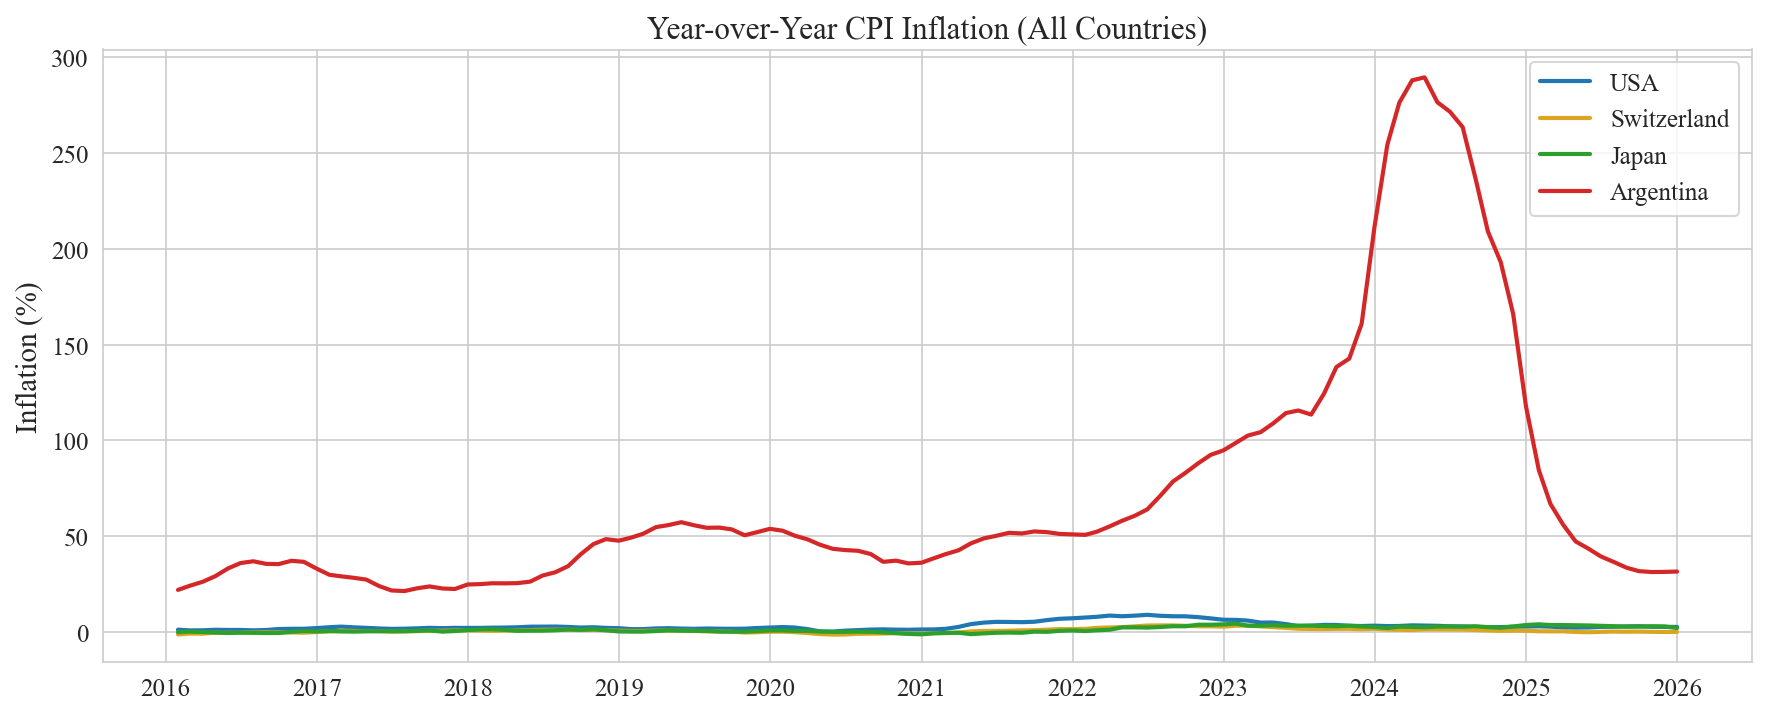

In [22]:
# YoY INFLATION: All four countries

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_us['date'], df_us['cpi_yoy'], label='USA', color=BTC_COLOR)
ax.plot(df_ch['date'], df_ch['cpi_yoy'], label='Switzerland', color=GOLD_COLOR)
ax.plot(df_jp['date'], df_jp['cpi_yoy'], label='Japan', color=RATE_COLOR)
ax.plot(df_ar['date'], df_ar['cpi_yoy'], label='Argentina', color=INFLATION_COLOR)
ax.set_title('Year-over-Year CPI Inflation (All Countries)')
ax.set_ylabel('Inflation (%)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'inflation_yoy_all.png'), dpi=150, bbox_inches='tight')
plt.show()

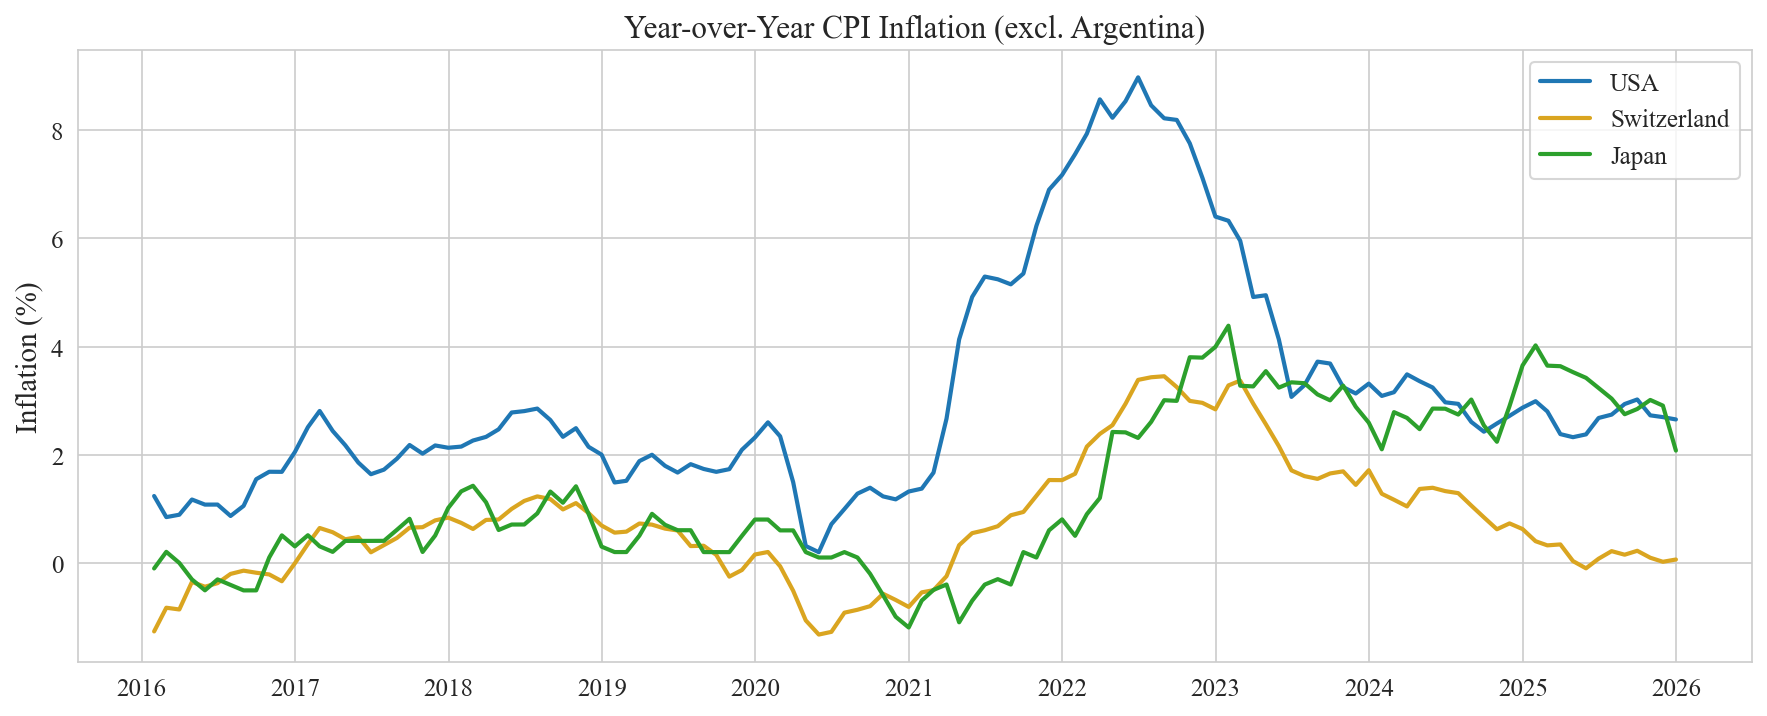

In [23]:
# YoY INFLATION: USA, Switzerland, Japan (without Argentina for better readability)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_us['date'], df_us['cpi_yoy'], label='USA', color=BTC_COLOR)
ax.plot(df_ch['date'], df_ch['cpi_yoy'], label='Switzerland', color=GOLD_COLOR)
ax.plot(df_jp['date'], df_jp['cpi_yoy'], label='Japan', color=RATE_COLOR)
ax.set_title('Year-over-Year CPI Inflation (excl. Argentina)')
ax.set_ylabel('Inflation (%)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'inflation_yoy_3countries.png'), dpi=150, bbox_inches='tight')
plt.show()

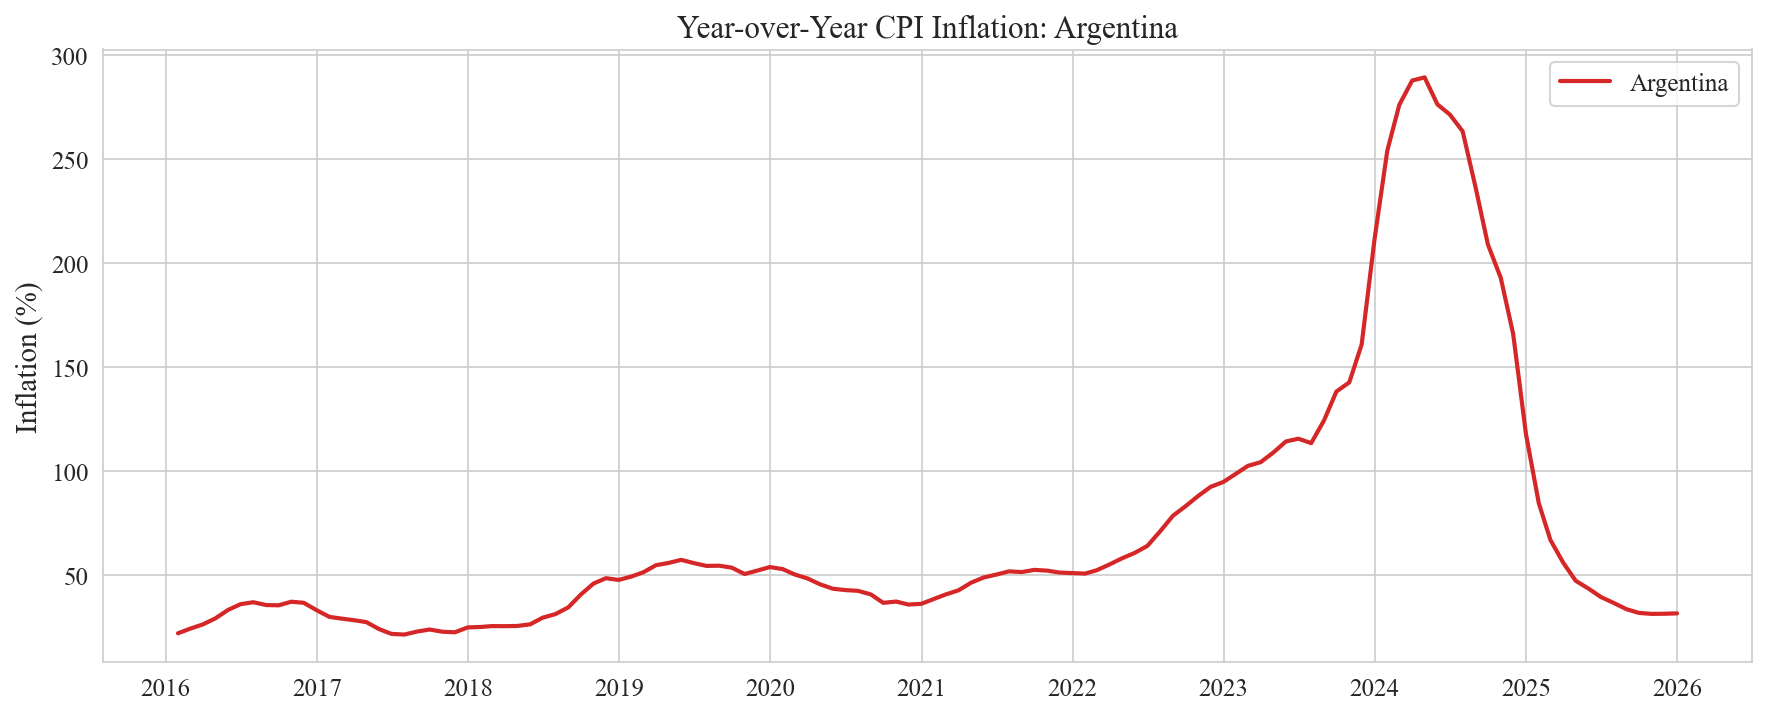

In [24]:
# YoY INFLATION: Argentina (separate plot due to different scale)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_ar['date'], df_ar['cpi_yoy'], label='Argentina', color=INFLATION_COLOR)
ax.set_title('Year-over-Year CPI Inflation: Argentina')
ax.set_ylabel('Inflation (%)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'inflation_yoy_argentina.png'), dpi=150, bbox_inches='tight')
plt.show()

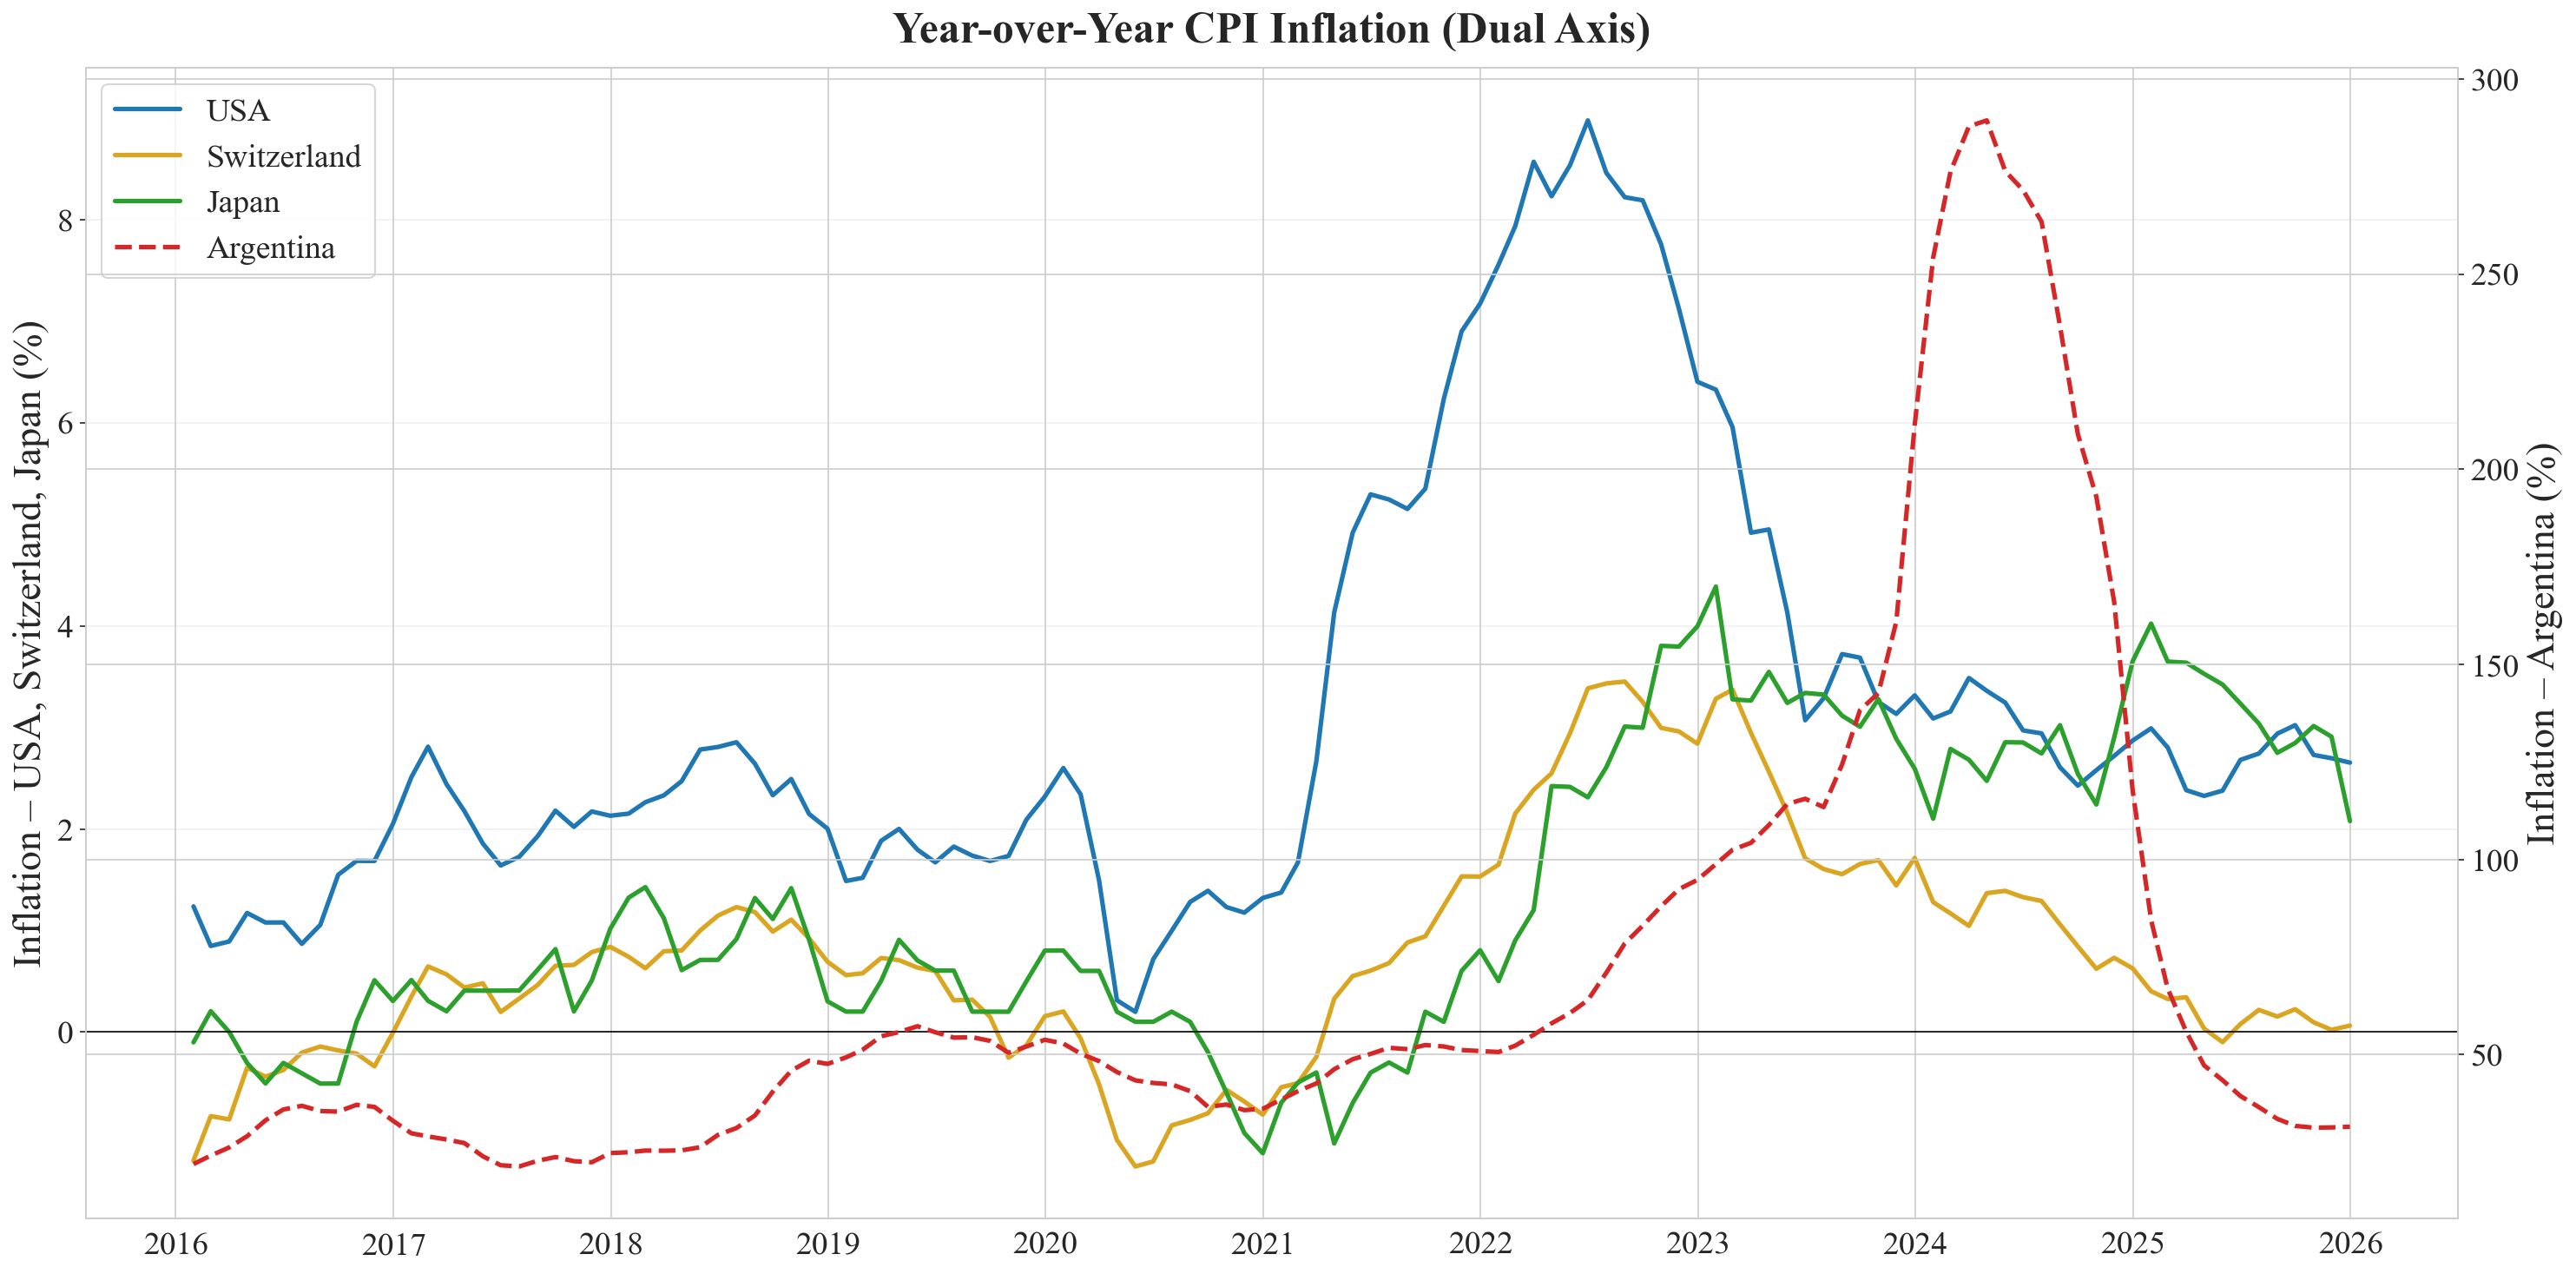

In [25]:
# YoY INFLATION: Dual y-axis (USA/CH/JP left, Argentina right)
fig, ax1 = plt.subplots(figsize=(20, 10))

# Left y-axis: USA, Switzerland, Japan
ax1.plot(df_us['date'], df_us['cpi_yoy'], label='USA', color=BTC_COLOR, linewidth=2.5)
ax1.plot(df_ch['date'], df_ch['cpi_yoy'], label='Switzerland', color=GOLD_COLOR, linewidth=2.5)
ax1.plot(df_jp['date'], df_jp['cpi_yoy'], label='Japan', color=RATE_COLOR, linewidth=2.5)
ax1.set_ylabel('Inflation – USA, Switzerland, Japan (%)', fontsize=22)
ax1.set_xlabel('')
ax1.tick_params(axis='both', which='major', labelsize=18)
ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax1.grid(axis='y', alpha=0.3)

# Right y-axis: Argentina
ax2 = ax1.twinx()
ax2.plot(df_ar['date'], df_ar['cpi_yoy'], label='Argentina',
         color=INFLATION_COLOR, linestyle='--', linewidth=2.5)
ax2.set_ylabel('Inflation – Argentina (%)', fontsize=22)
ax2.tick_params(axis='y', which='major', labelsize=18)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=18)

ax1.set_title('Year-over-Year CPI Inflation (Dual Axis)',
              fontsize=24, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'inflation_yoy_dual_axis.png'),
            dpi=300, bbox_inches='tight')
plt.show()

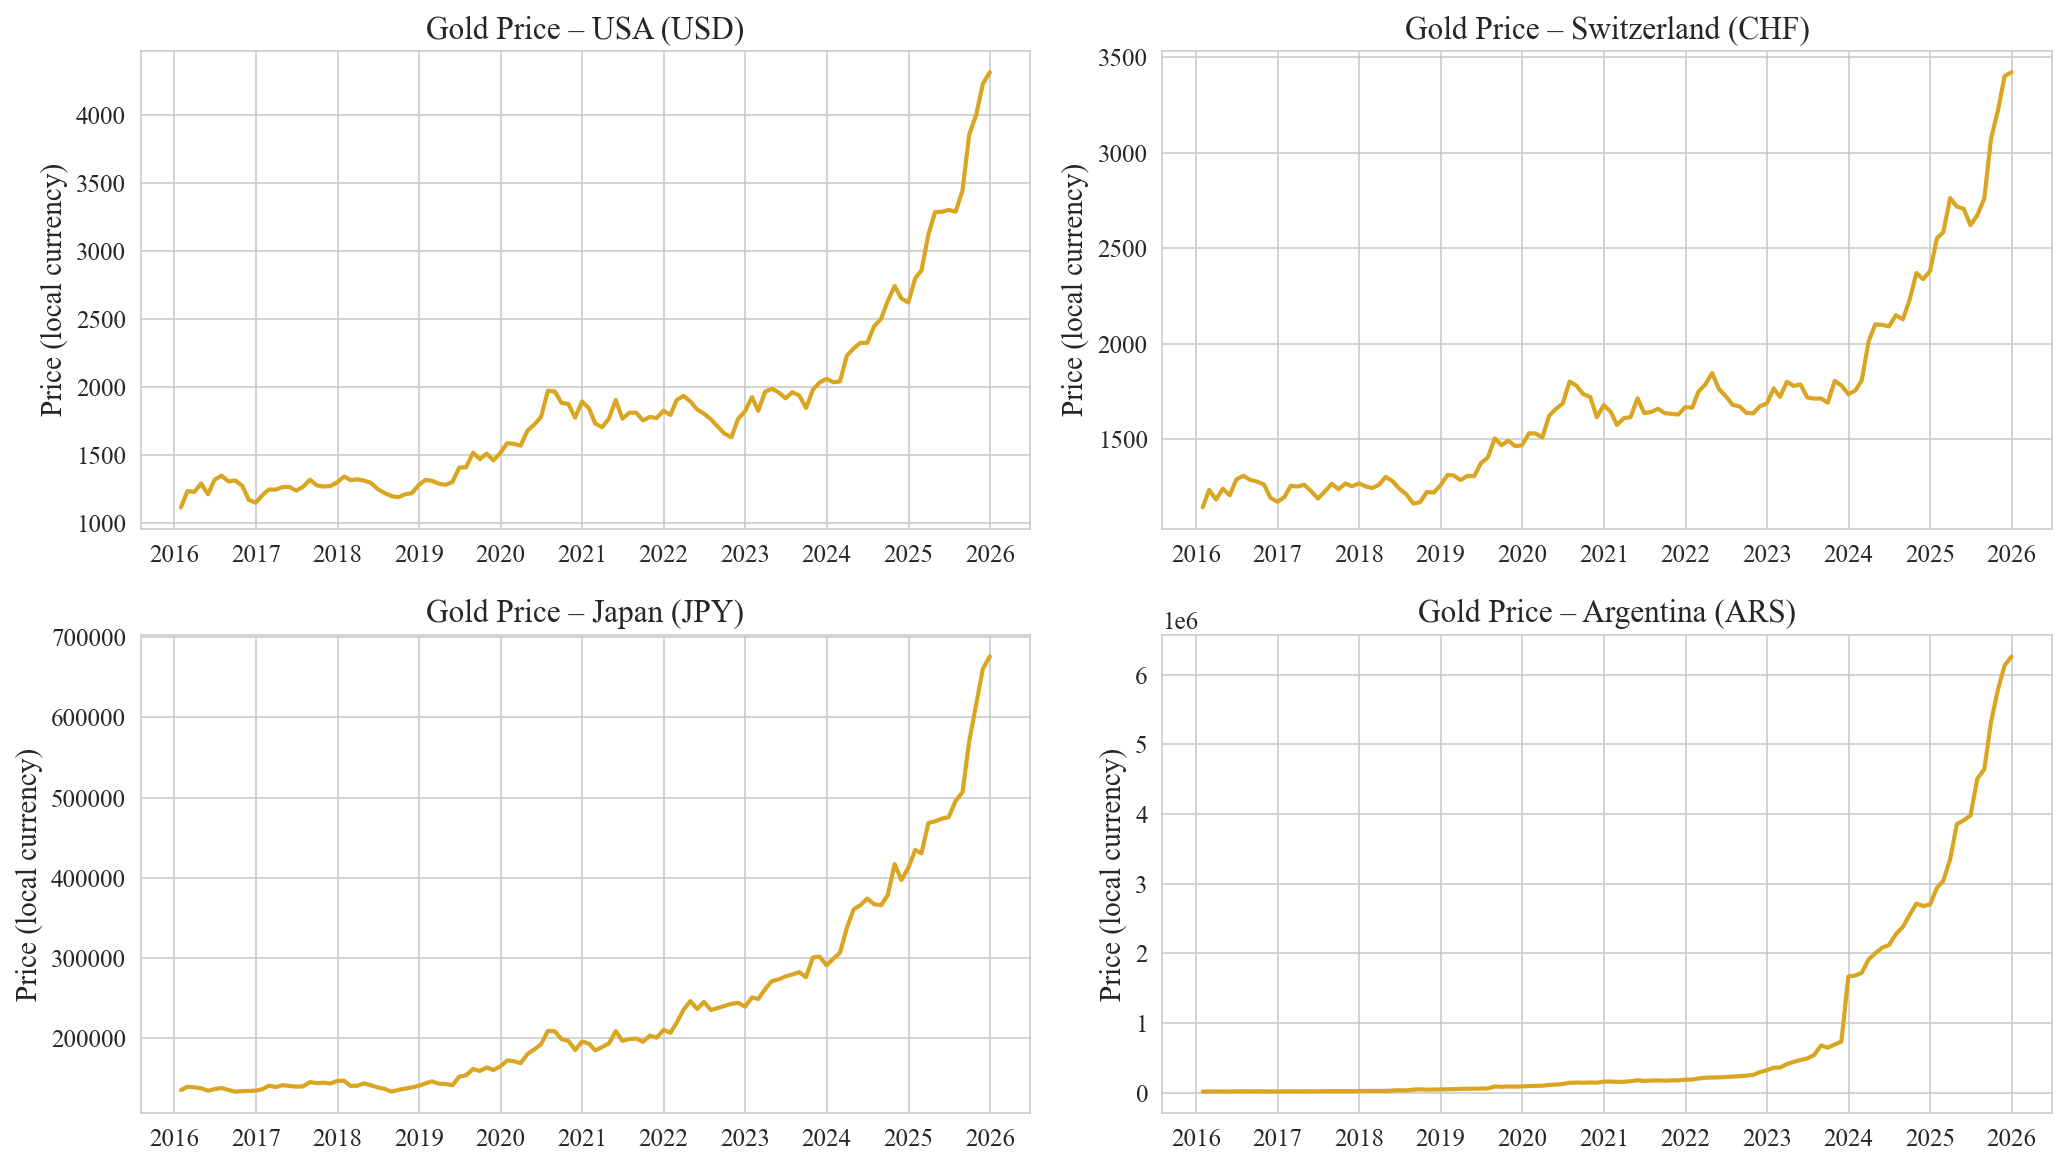

In [26]:
# GOLD PRICE IN LOCAL CURRENCY (all countries)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, df) in zip(axes.flat, [
    ('USA (USD)', df_us), ('Switzerland (CHF)', df_ch),
    ('Japan (JPY)', df_jp), ('Argentina (ARS)', df_ar)
]):
    ax.plot(df['date'], df['gold_price_local'], color=GOLD_COLOR)
    ax.set_title(f'Gold Price – {name}')
    ax.set_ylabel('Price (local currency)')

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'gold_price_local.png'), dpi=150, bbox_inches='tight')
plt.show()

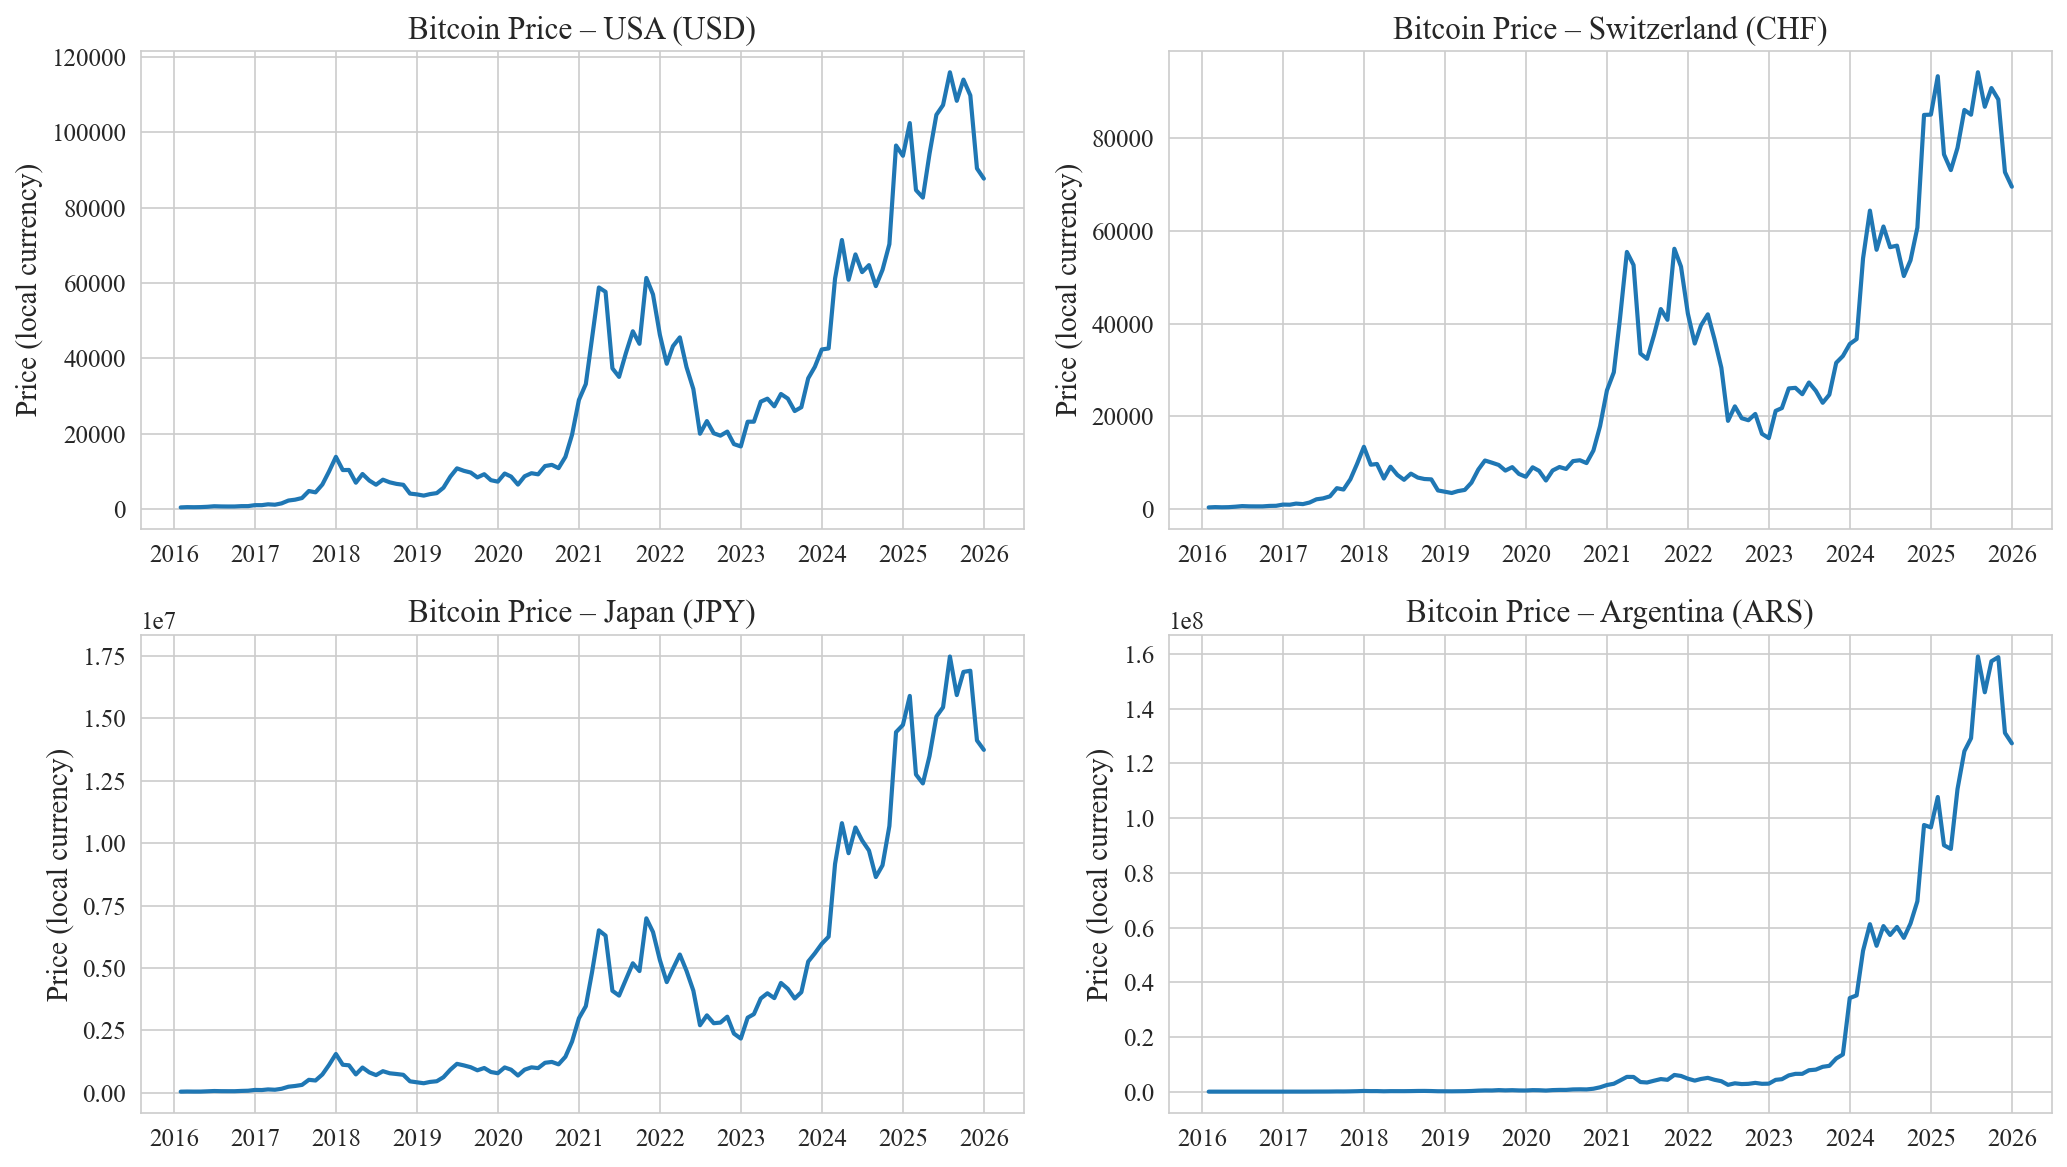

In [27]:
# BITCOIN PRICE IN LOCAL CURRENCY (all countries)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, df) in zip(axes.flat, [
    ('USA (USD)', df_us), ('Switzerland (CHF)', df_ch),
    ('Japan (JPY)', df_jp), ('Argentina (ARS)', df_ar)
]):
    ax.plot(df['date'], df['btc_price_local'], color=BTC_COLOR)
    ax.set_title(f'Bitcoin Price – {name}')
    ax.set_ylabel('Price (local currency)')

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'btc_price_local.png'), dpi=150, bbox_inches='tight')
plt.show()

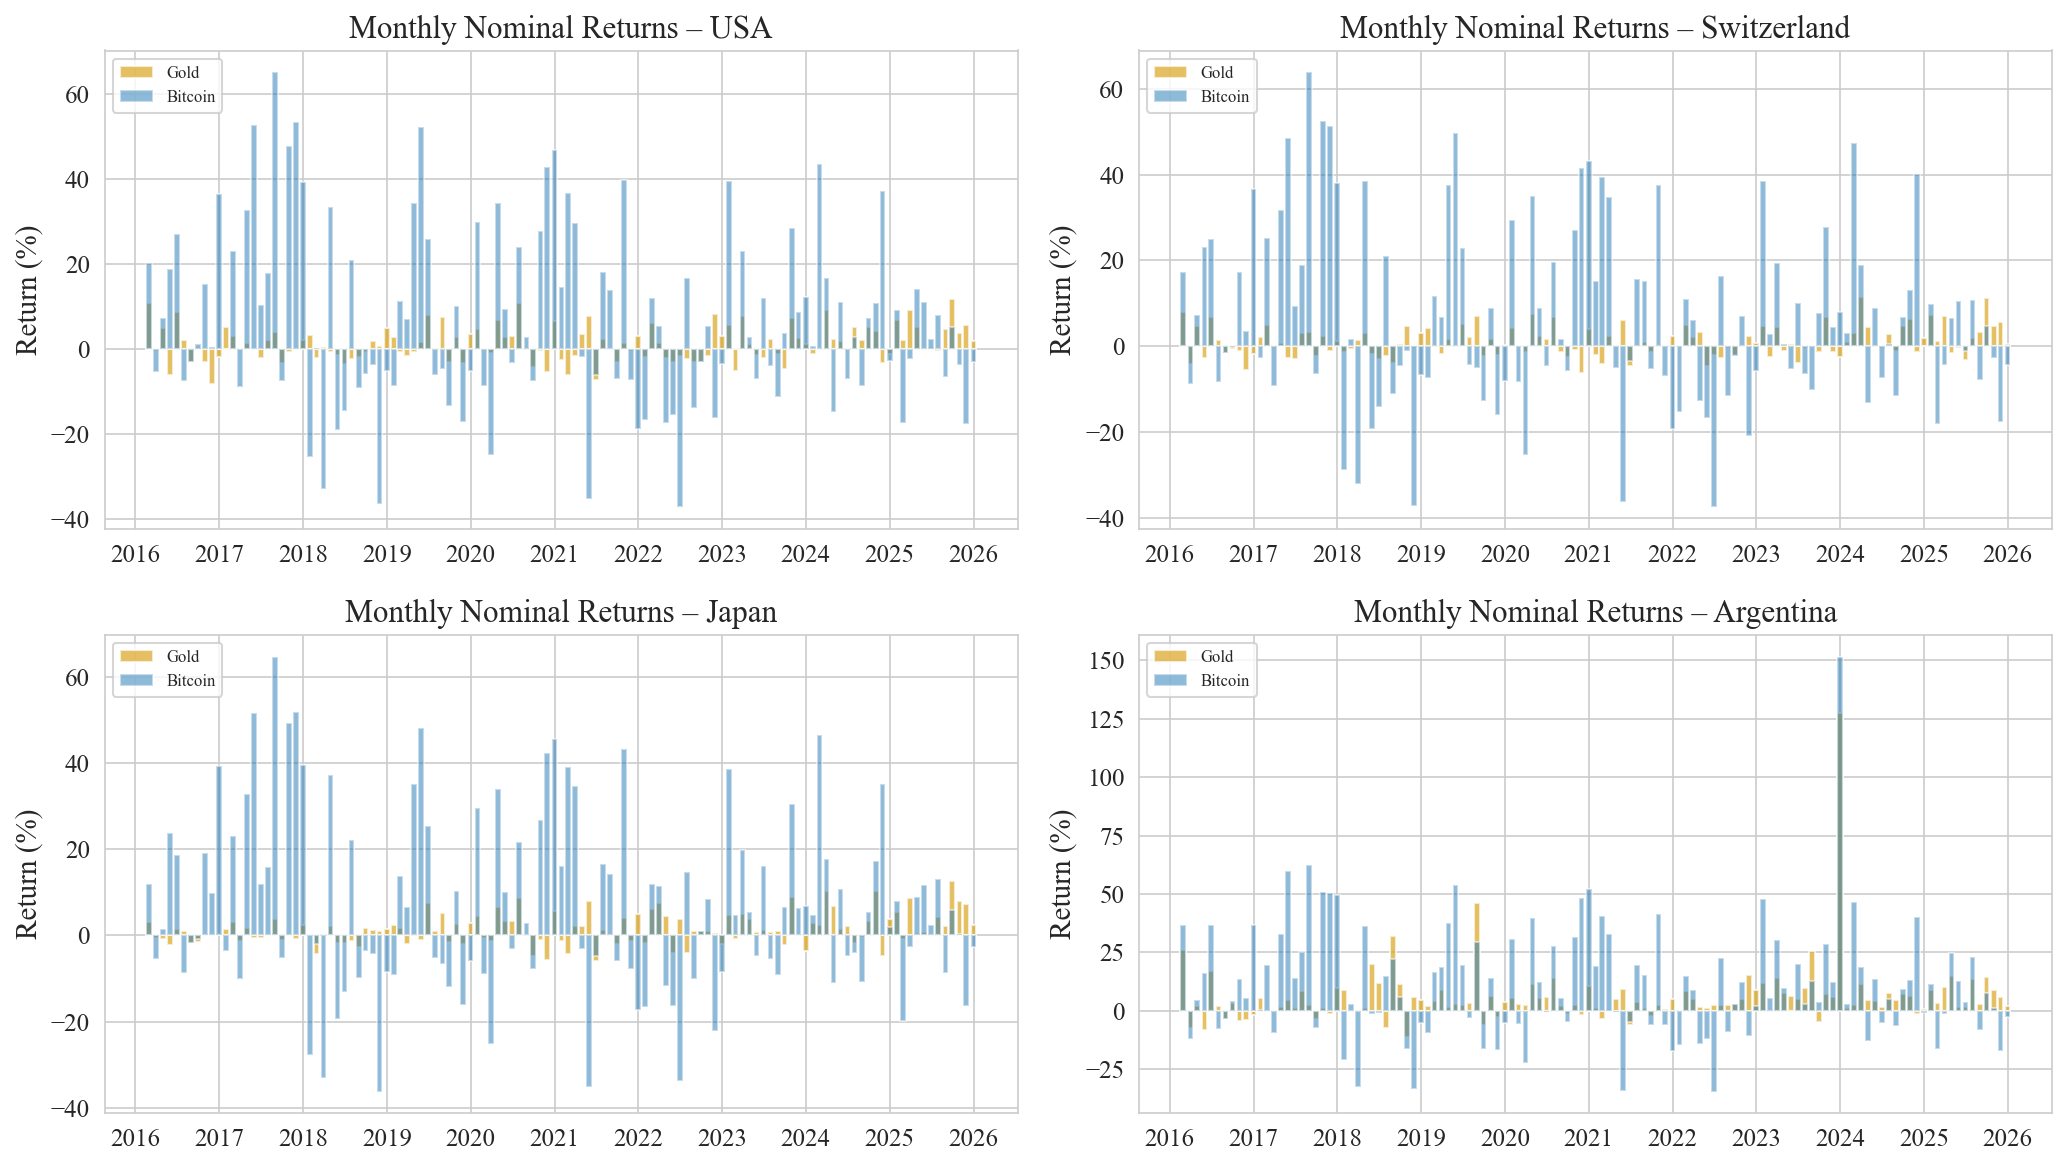

In [28]:
# MONTHLY NOMINAL RETURNS: Gold vs Bitcoin

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, df) in zip(axes.flat, [
    ('USA', df_us), ('Switzerland', df_ch), ('Japan', df_jp), ('Argentina', df_ar)
]):
    ax.bar(df['date'], df['gold_ret'], width=25, alpha=0.7, color=GOLD_COLOR, label='Gold')
    ax.bar(df['date'], df['btc_ret'], width=25, alpha=0.5, color=BTC_COLOR, label='Bitcoin')
    ax.set_title(f'Monthly Nominal Returns – {name}')
    ax.set_ylabel('Return (%)')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'nominal_returns_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

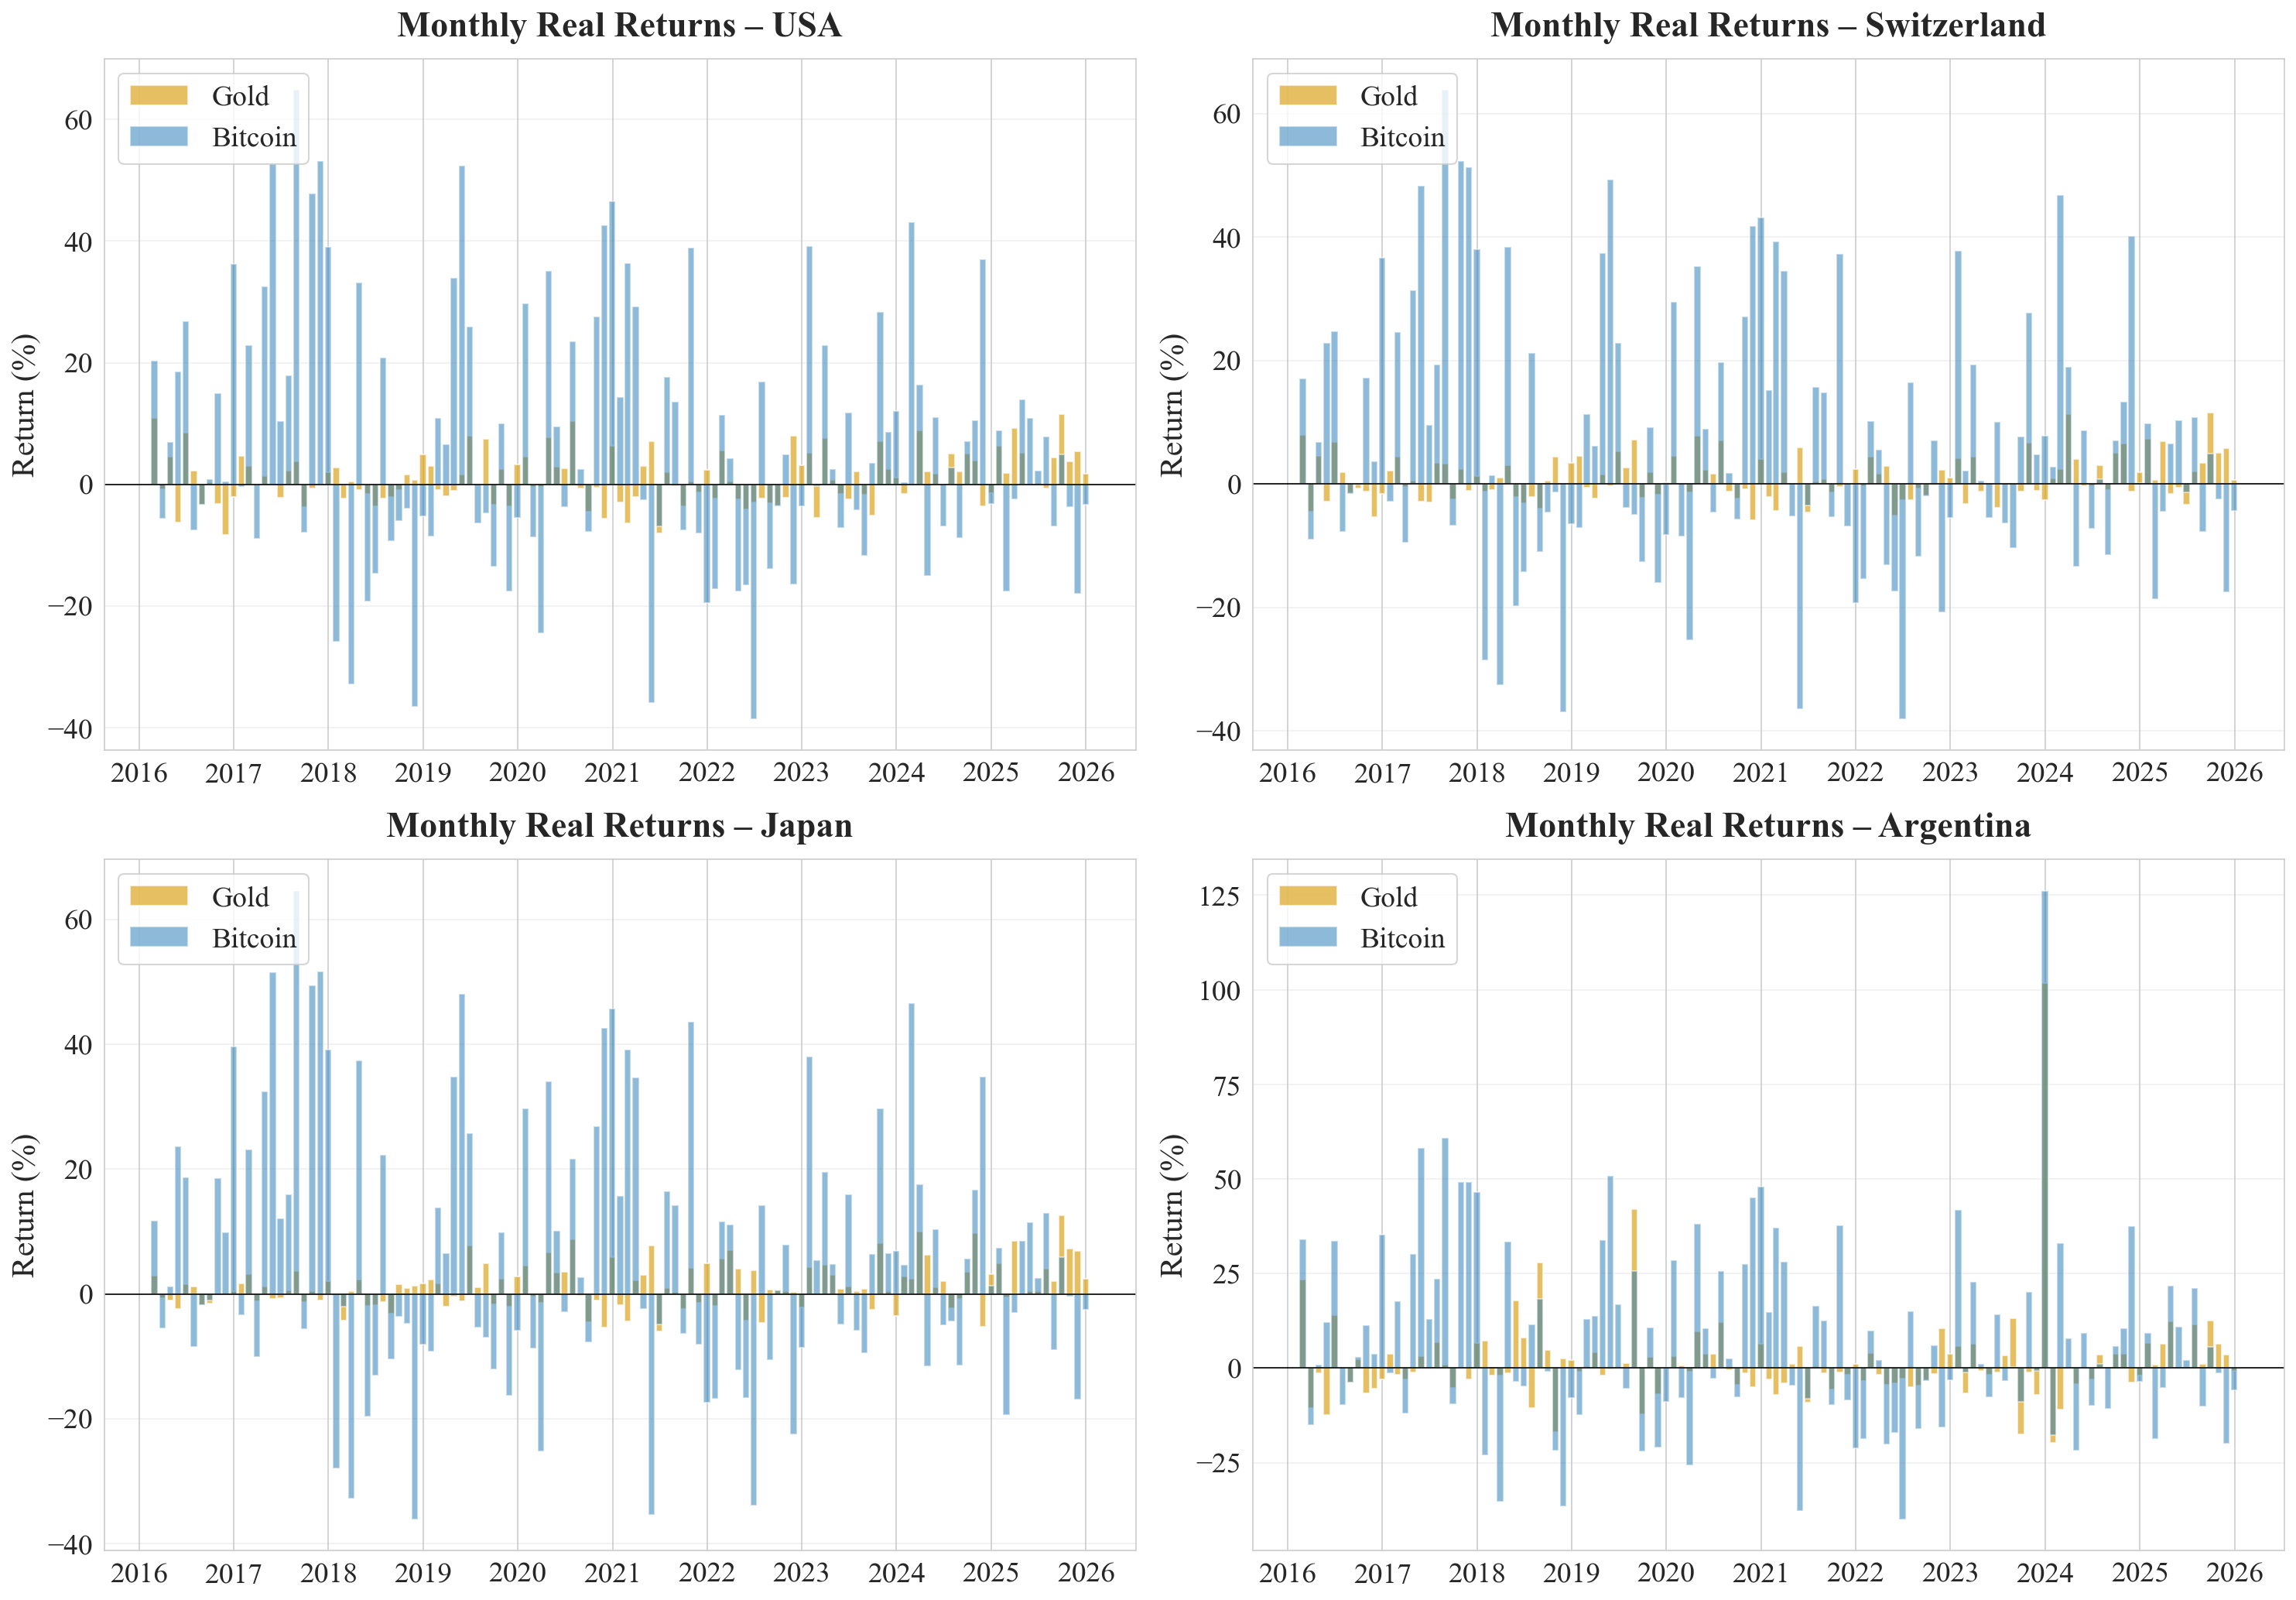

In [29]:
# MONTHLY REAL RETURNS: Gold vs Bitcoin

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

for ax, (name, df) in zip(axes.flat, [
    ('USA', df_us), ('Switzerland', df_ch), ('Japan', df_jp), ('Argentina', df_ar)
]):
    ax.bar(df['date'], df['gold_real_ret'], width=25, alpha=0.7, color=GOLD_COLOR, label='Gold')
    ax.bar(df['date'], df['btc_real_ret'], width=25, alpha=0.5, color=BTC_COLOR, label='Bitcoin')
    ax.set_title(f'Monthly Real Returns – {name}', fontsize=22, fontweight='bold', pad=14)
    ax.set_ylabel('Return (%)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.legend(loc='upper left', fontsize=18)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'real_returns_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

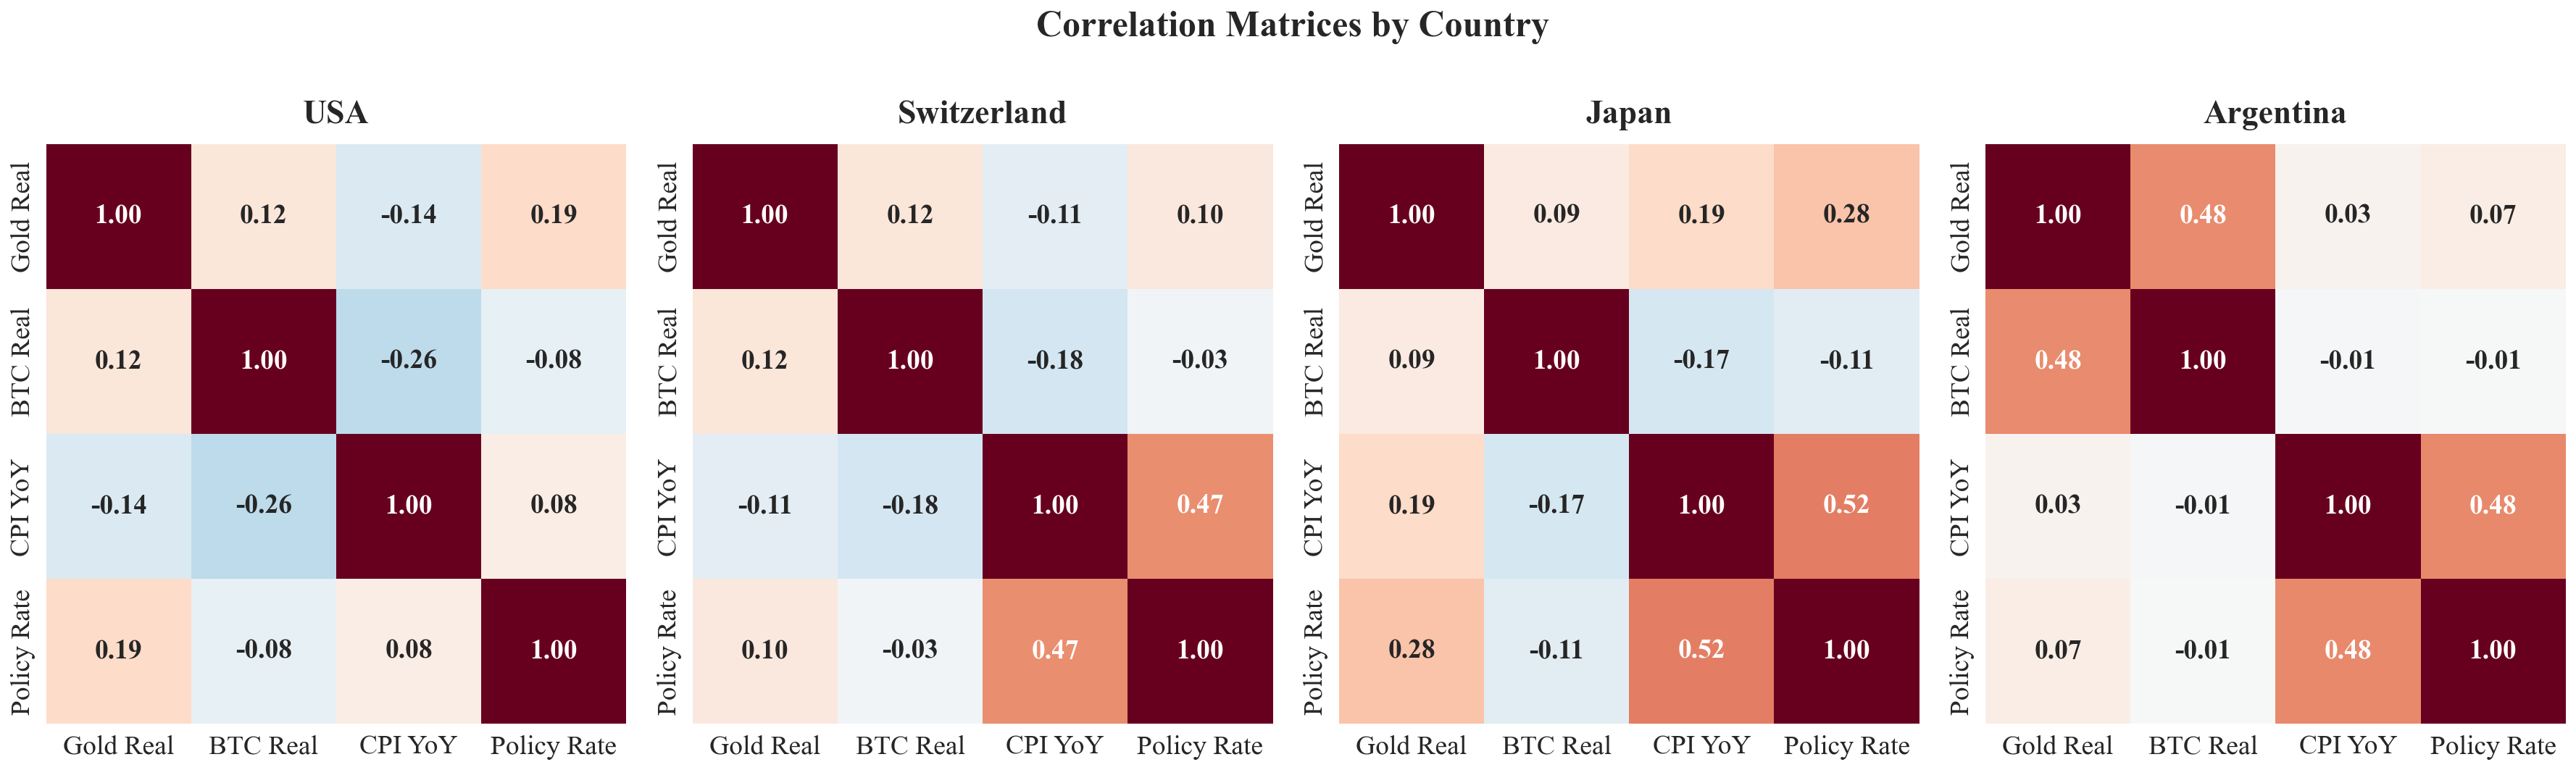

In [30]:
# CORRELATION MATRICES
fig, axes = plt.subplots(1, 4, figsize=(24, 7))

for ax, (name, df) in zip(axes, [
    ('USA', df_us), ('Switzerland', df_ch), ('Japan', df_jp), ('Argentina', df_ar)
]):
    corr_cols = ['gold_real_ret', 'btc_real_ret', 'cpi_yoy', 'policy_rate']
    corr_labels = ['Gold Real', 'BTC Real', 'CPI YoY', 'Policy Rate']
    corr = df[corr_cols].dropna().corr()
    corr.index = corr_labels
    corr.columns = corr_labels

    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, square=True, cbar=False,
                annot_kws={'size': 18, 'weight': 'bold'})
    ax.set_title(name, fontsize=22, weight='bold', pad=14)
    ax.tick_params(axis='both', which='major', labelsize=18)

plt.suptitle('Correlation Matrices by Country', fontsize=24, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'correlation_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()

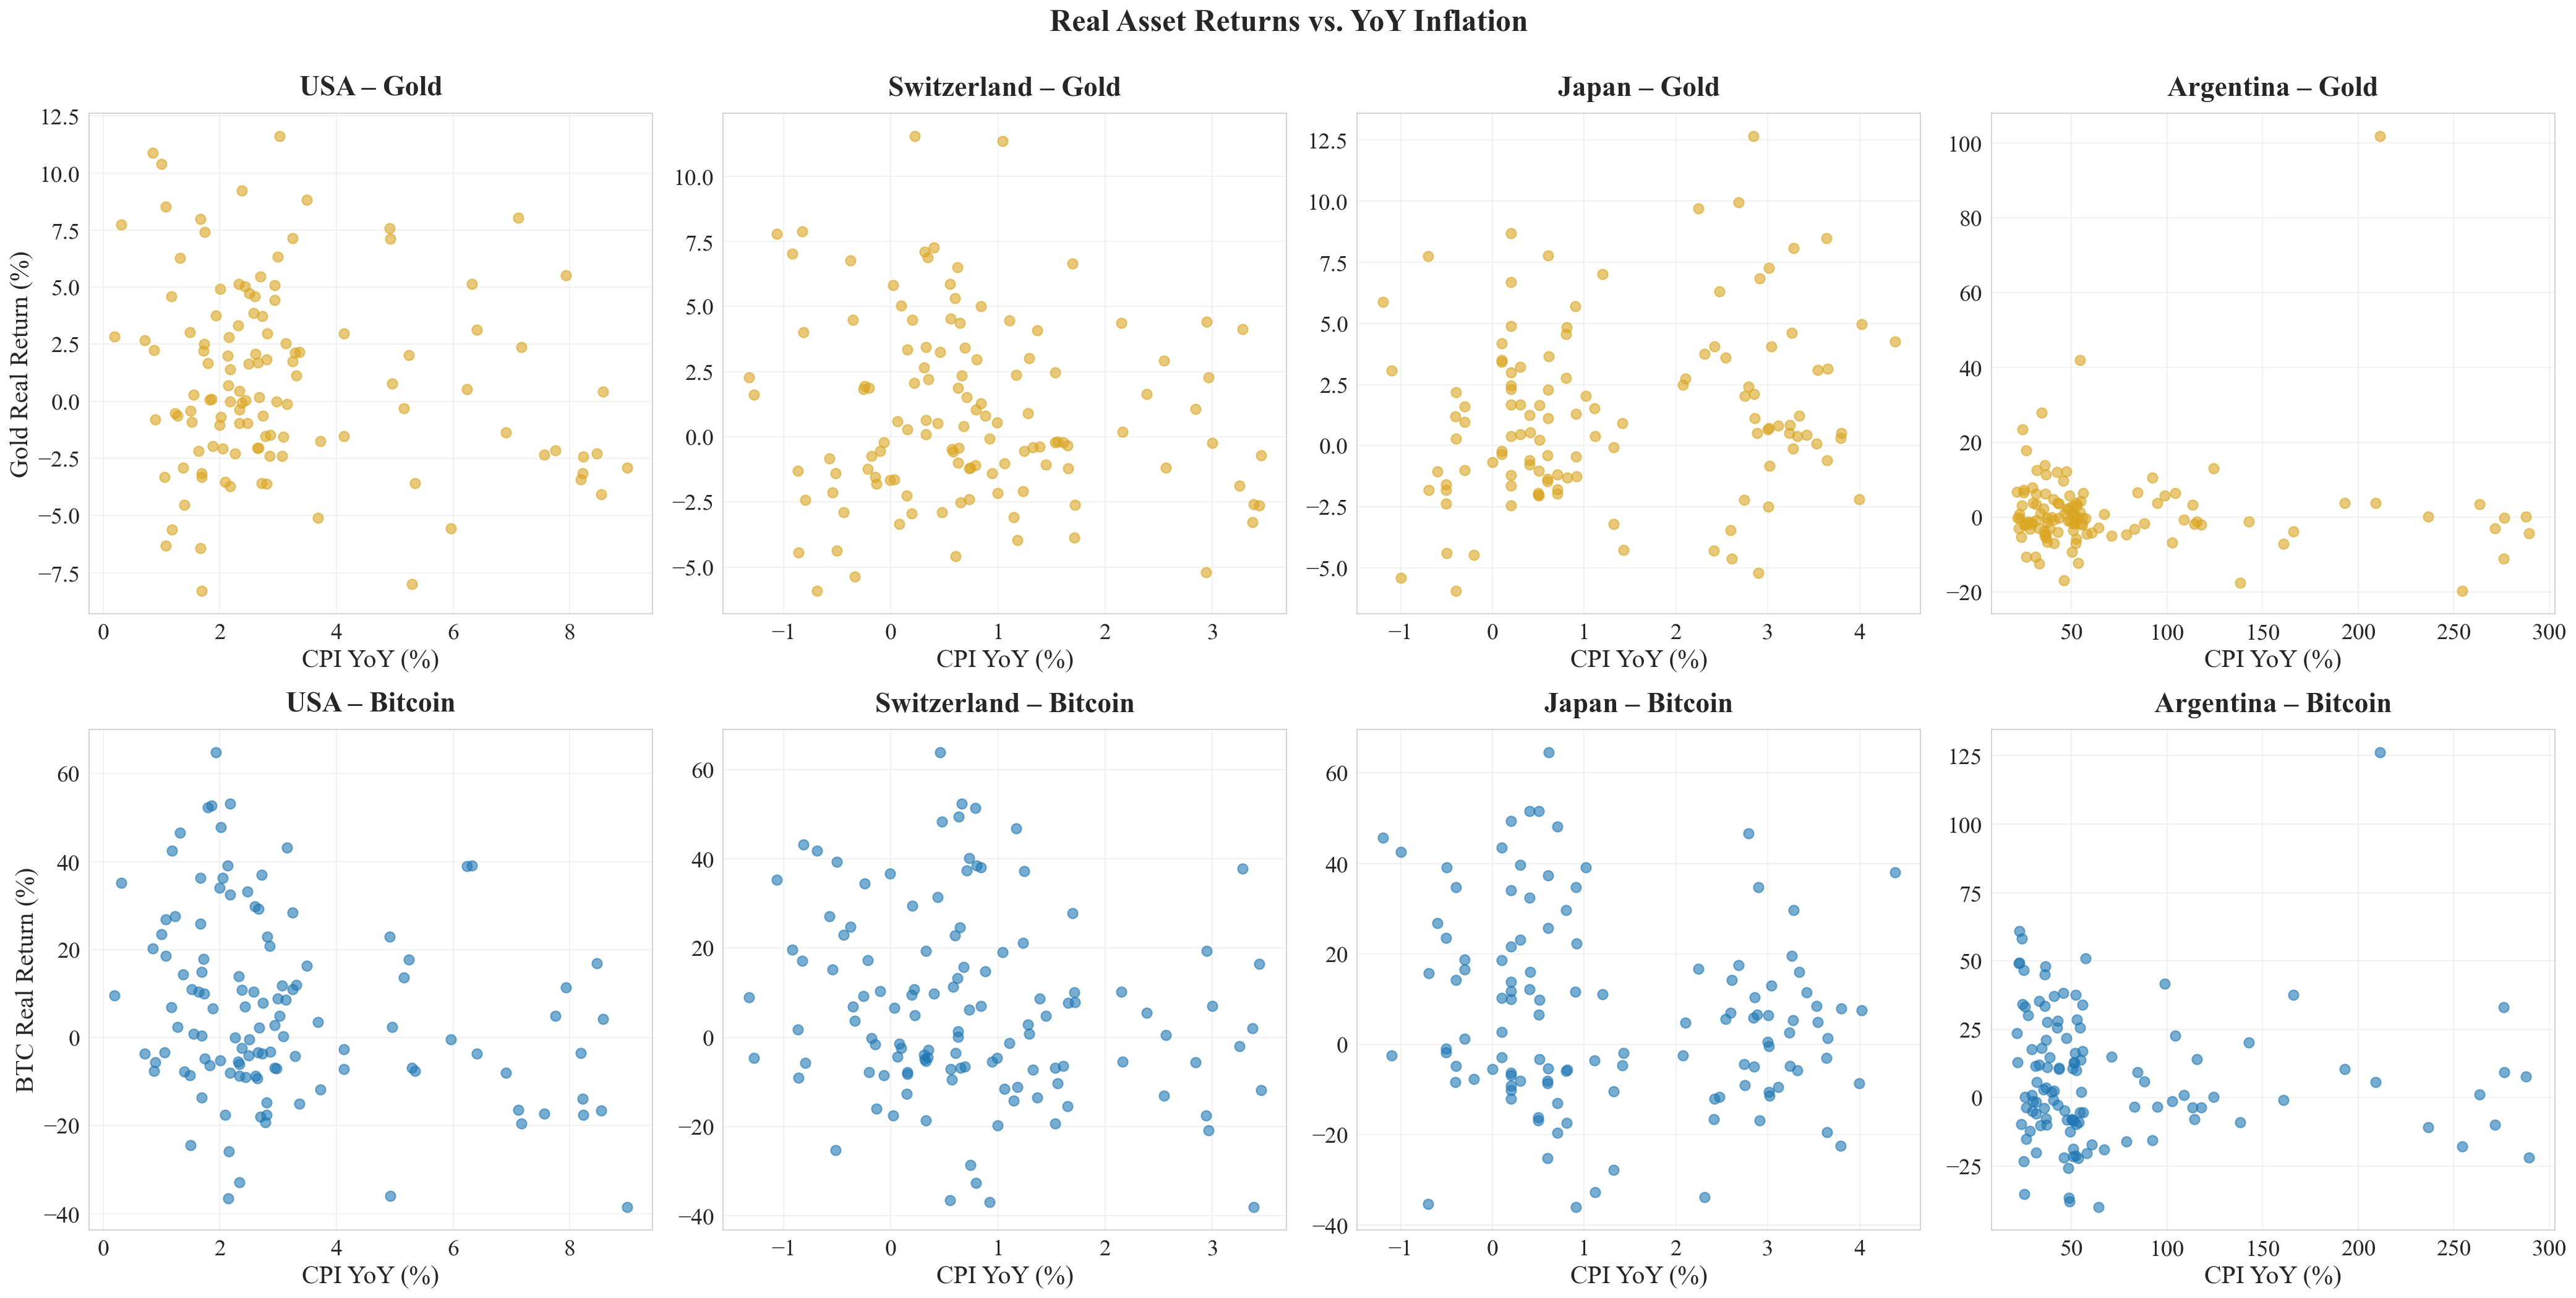

In [31]:
# SCATTER PLOTS: Real Returns vs YoY Inflation
fig, axes = plt.subplots(2, 4, figsize=(28, 14))

for col_idx, (name, df) in enumerate([
    ('USA', df_us), ('Switzerland', df_ch), ('Japan', df_jp), ('Argentina', df_ar)
]):
    # Gold
    ax = axes[0, col_idx]
    ax.scatter(df['cpi_yoy'], df['gold_real_ret'], color=GOLD_COLOR, alpha=0.6, s=60)
    ax.set_title(f'{name} – Gold', fontsize=22, weight='bold', pad=14)
    ax.set_xlabel('CPI YoY (%)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.grid(axis='both', alpha=0.3)
    if col_idx == 0:
        ax.set_ylabel('Gold Real Return (%)', fontsize=20)

    # Bitcoin
    ax = axes[1, col_idx]
    ax.scatter(df['cpi_yoy'], df['btc_real_ret'], color=BTC_COLOR, alpha=0.6, s=60)
    ax.set_title(f'{name} – Bitcoin', fontsize=22, weight='bold', pad=14)
    ax.set_xlabel('CPI YoY (%)', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.grid(axis='both', alpha=0.3)
    if col_idx == 0:
        ax.set_ylabel('BTC Real Return (%)', fontsize=20)

plt.suptitle('Real Asset Returns vs. YoY Inflation', fontsize=24, weight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'scatter_returns_inflation.png'), dpi=300, bbox_inches='tight')
plt.show()

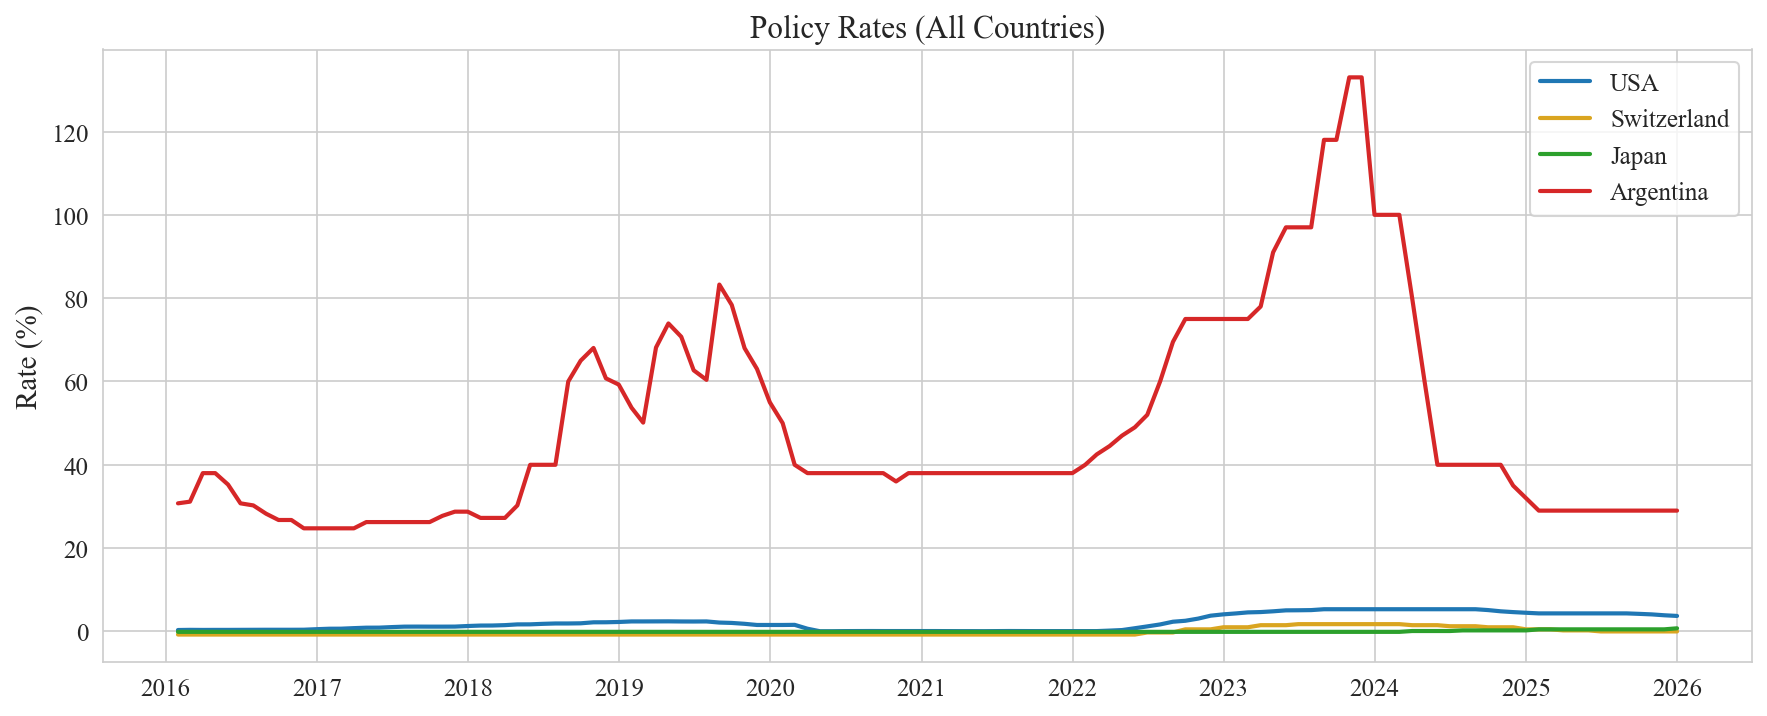

In [32]:
# POLICY RATES: All four countries

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_us['date'], df_us['policy_rate'], label='USA', color=BTC_COLOR)
ax.plot(df_ch['date'], df_ch['policy_rate'], label='Switzerland', color=GOLD_COLOR)
ax.plot(df_jp['date'], df_jp['policy_rate'], label='Japan', color=RATE_COLOR)
ax.plot(df_ar['date'], df_ar['policy_rate'], label='Argentina', color=INFLATION_COLOR)
ax.set_title('Policy Rates (All Countries)')
ax.set_ylabel('Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'policy_rates_all.png'), dpi=150, bbox_inches='tight')
plt.show()

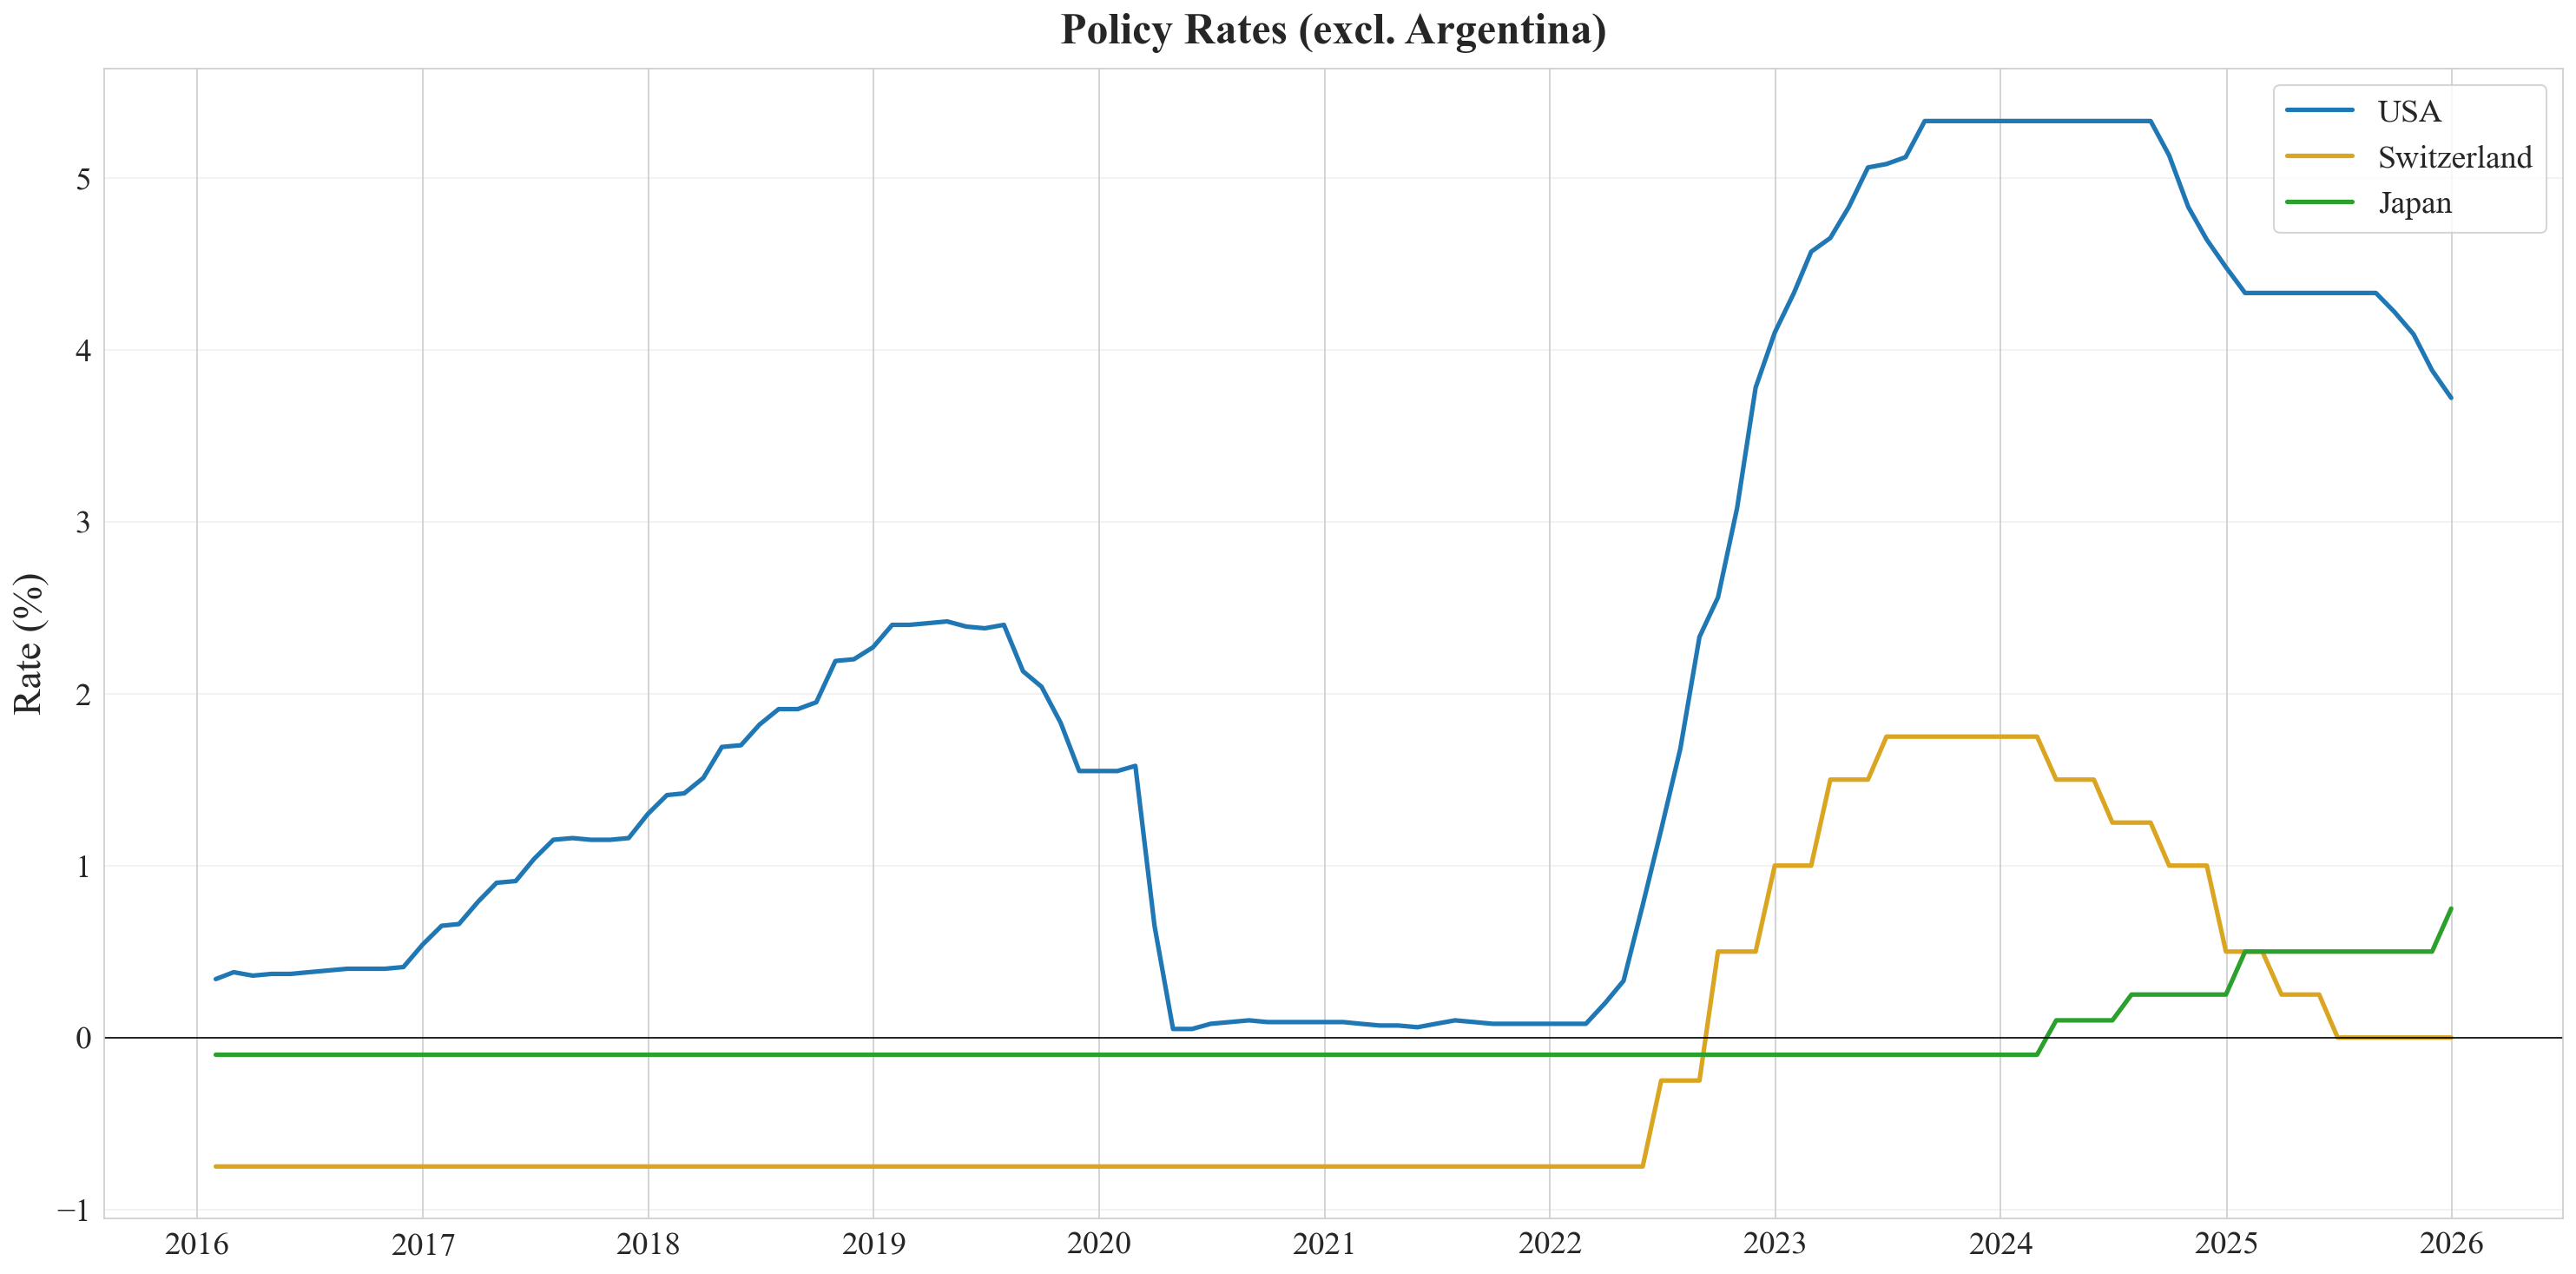

In [33]:
# POLICY RATES: USA, Switzerland, Japan (without Argentina for better readability)
fig, ax = plt.subplots(figsize=(20, 10))

ax.plot(df_us['date'], df_us['policy_rate'], label='USA', color=BTC_COLOR, linewidth=2.5)
ax.plot(df_ch['date'], df_ch['policy_rate'], label='Switzerland', color=GOLD_COLOR, linewidth=2.5)
ax.plot(df_jp['date'], df_jp['policy_rate'], label='Japan', color=RATE_COLOR, linewidth=2.5)

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

ax.set_title('Policy Rates (excl. Argentina)', fontsize=24, fontweight='bold', pad=14)
ax.set_ylabel('Rate (%)', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(loc='best', fontsize=18)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'policy_rates_3countries.png'), dpi=300, bbox_inches='tight')
plt.show()

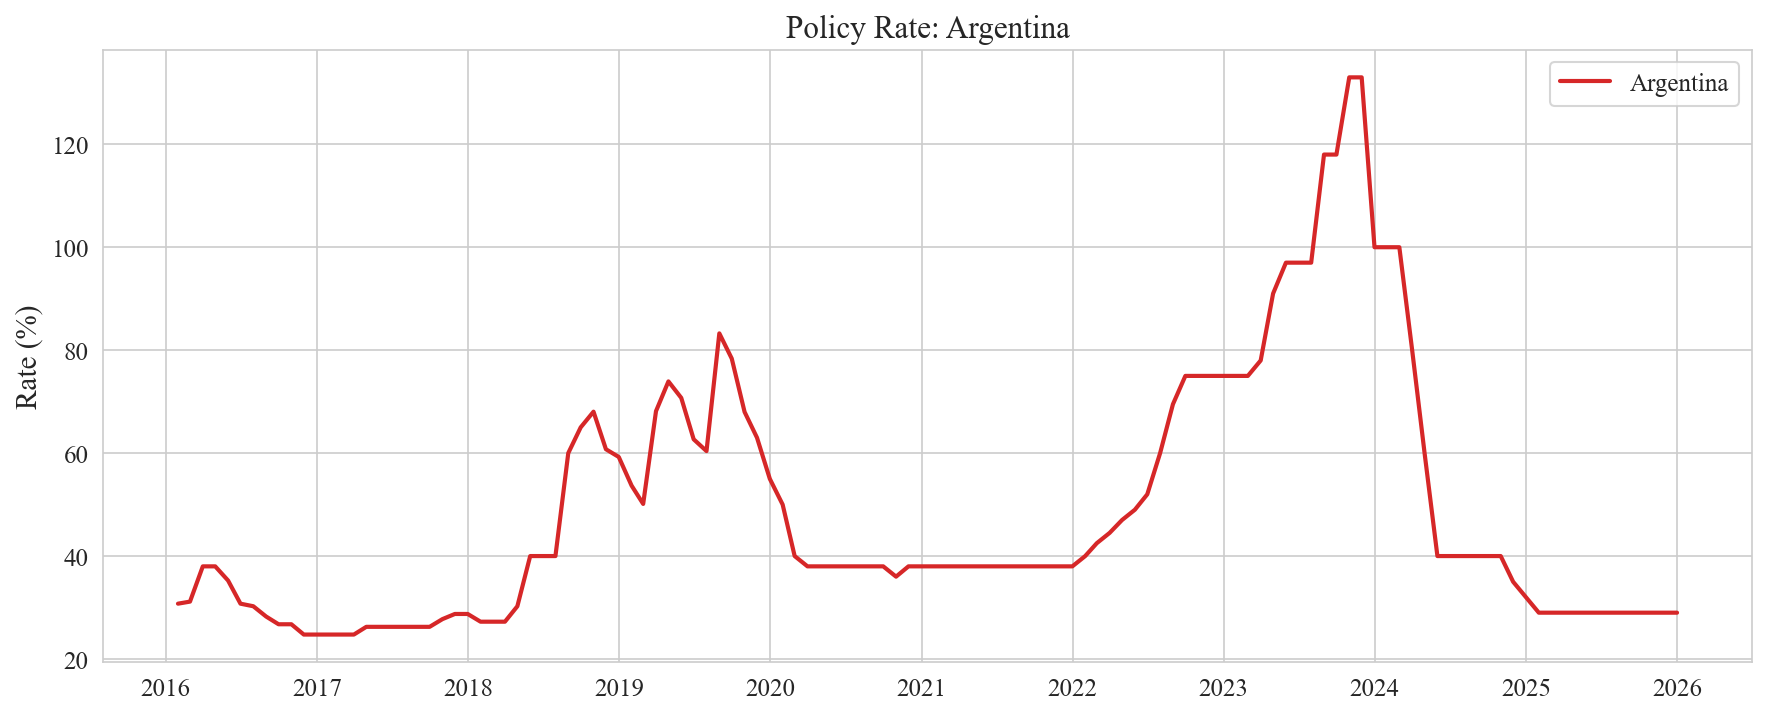

In [34]:
# POLICY RATE: Argentina (separate plot due to different scale)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_ar['date'], df_ar['policy_rate'], label='Argentina', color=INFLATION_COLOR)
ax.set_title('Policy Rate: Argentina')
ax.set_ylabel('Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'policy_rate_argentina.png'), dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# REGRESSION SETUP
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import jarque_bera
 
print('Regression libraries loaded.')

Regression libraries loaded.


In [36]:
# Real Returns

# Model: Real Return = α + β₁ × CPI YoY + β₂ × Policy Rate + ε

# β₁ = Inflation Beta (key variable of interest)
# β₂ = Policy Rate (control variable)

# I use Newey-West (HAC) standard errors to account for potential heteroskedasticity and autocorrelation.
 
results_main = []
 
for country, df in [('USA', df_us), ('Switzerland', df_ch), ('Japan', df_jp), ('Argentina', df_ar)]:
    for asset, ret_col in [('Gold', 'gold_real_ret'), ('Bitcoin', 'btc_real_ret')]:
 
        reg_data = df[[ret_col, 'cpi_yoy', 'policy_rate']].dropna()
 
        Y = reg_data[ret_col]
        X = reg_data[['cpi_yoy', 'policy_rate']]
        X = sm.add_constant(X)
 
        # OLS with standard errors (for diagnostics)
        model = sm.OLS(Y, X).fit()
 
        # OLS with Newey-West HAC standard errors (for inference)
        model_hac = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
 
        # Diagnostic tests
        resid = model.resid
 
        # Breusch-Pagan: tests for heteroskedasticity (H0: homoskedastic)
        bp_stat, bp_pval, _, _ = het_breuschpagan(resid, X)
 
        # Durbin-Watson: tests for autocorrelation (close to 2 = no autocorrelation)
        dw = durbin_watson(resid)
 
        # Jarque-Bera: tests for normality of residuals (H0: normal)
        jb_stat, jb_pval = jarque_bera(resid)[:2]
 
        # Store results
        results_main.append({
            'Country': country,
            'Asset': asset,
            'Obs': int(model.nobs),
            'Inflation Beta': model_hac.params['cpi_yoy'],
            'Beta p-value': model_hac.pvalues['cpi_yoy'],
            'Policy Rate Coef': model_hac.params['policy_rate'],
            'Rate p-value': model_hac.pvalues['policy_rate'],
            'Constant': model_hac.params['const'],
            'R-squared': model.rsquared,
            'Durbin-Watson': dw,
            'BP p-value': bp_pval,
            'JB p-value': jb_pval
        })
 
        # Print detailed output
        print(f'\n{"─"*70}')
        print(f'  {country} – {asset} (Real Return)')
        print(f'{"─"*70}')
        print(f'  Observations:      {int(model.nobs)}')
        print(f'  R-squared:         {model.rsquared:.4f}')
        print(f'')
        print(f'  Inflation Beta:    {model_hac.params["cpi_yoy"]:.4f}  (p = {model_hac.pvalues["cpi_yoy"]:.4f})')
        print(f'  Policy Rate:       {model_hac.params["policy_rate"]:.4f}  (p = {model_hac.pvalues["policy_rate"]:.4f})')
        print(f'  Constant:          {model_hac.params["const"]:.4f}  (p = {model_hac.pvalues["const"]:.4f})')
        print(f'')
        print(f'  Durbin-Watson:     {dw:.3f}')
        print(f'  Breusch-Pagan p:   {bp_pval:.4f} {"** heteroskedasticity" if bp_pval < 0.05 else "(ok)"}')
        print(f'  Jarque-Bera p:     {jb_pval:.4f} {"** non-normal residuals" if jb_pval < 0.05 else "(ok)"}')
 
print('\nMain model regressions complete.')


──────────────────────────────────────────────────────────────────────
  USA – Gold (Real Return)
──────────────────────────────────────────────────────────────────────
  Observations:      119
  R-squared:         0.0613

  Inflation Beta:    -0.3063  (p = 0.0660)
  Policy Rate:       0.4372  (p = 0.0131)
  Constant:          0.9568  (p = 0.2462)

  Durbin-Watson:     2.012
  Breusch-Pagan p:   0.4862 (ok)
  Jarque-Bera p:     0.1977 (ok)

──────────────────────────────────────────────────────────────────────
  USA – Bitcoin (Real Return)
──────────────────────────────────────────────────────────────────────
  Observations:      119
  R-squared:         0.0724

  Inflation Beta:    -2.5701  (p = 0.0004)
  Policy Rate:       -0.6580  (p = 0.4252)
  Constant:          15.9924  (p = 0.0006)

  Durbin-Watson:     1.802
  Breusch-Pagan p:   0.1452 (ok)
  Jarque-Bera p:     0.2102 (ok)

──────────────────────────────────────────────────────────────────────
  Switzerland – Gold (Real Return

In [37]:
# SUMMARY TABLE: Real Returns
 
summary_main = pd.DataFrame(results_main)
 
print('=' * 80)
print('  INFLATION BETAS – Main Model (Real Returns, HAC Standard Errors)')
print('=' * 80)
print()
print(summary_main[['Country', 'Asset', 'Obs', 'Inflation Beta', 'Beta p-value',
                     'Policy Rate Coef', 'Rate p-value', 'R-squared']].to_string(index=False, float_format='%.4f'))
 
print('\n\nSignificance: *** p < 0.01, ** p < 0.05, * p < 0.10')
print('\nInterpretation: A positive and significant Inflation Beta means the')
print('asset provides a hedge against inflation in that country.')

  INFLATION BETAS – Main Model (Real Returns, HAC Standard Errors)

    Country   Asset  Obs  Inflation Beta  Beta p-value  Policy Rate Coef  Rate p-value  R-squared
        USA    Gold  119         -0.3063        0.0660            0.4372        0.0131     0.0613
        USA Bitcoin  119         -2.5701        0.0004           -0.6580        0.4252     0.0724
Switzerland    Gold  119         -0.6276        0.0363            0.7639        0.0425     0.0414
Switzerland Bitcoin  119         -4.0853        0.0170            1.5795        0.4646     0.0377
      Japan    Gold  119          0.1366        0.4364            4.5105        0.0063     0.0835
      Japan Bitcoin  119         -2.2262        0.1639           -3.3974        0.6675     0.0307
  Argentina    Gold  119         -0.0001        0.9944            0.0356        0.3474     0.0052
  Argentina Bitcoin  119         -0.0035        0.9228           -0.0015        0.9874     0.0001


Significance: *** p < 0.01, ** p < 0.05, * p < 0

In [38]:
# DIAGNOSTIC SUMMARY
 
print('=' * 80)
print('  DIAGNOSTIC TESTS')
print('=' * 80)
print()
print(summary_main[['Country', 'Asset', 'Durbin-Watson', 'BP p-value', 'JB p-value']].to_string(index=False, float_format='%.4f'))
print()
print('Durbin-Watson: close to 2 = no autocorrelation (< 1.5 or > 2.5 is concerning)')
print('Breusch-Pagan: p < 0.05 = heteroskedasticity detected (HAC corrects for this)')
print('Jarque-Bera:   p < 0.05 = residuals are not normally distributed')

  DIAGNOSTIC TESTS

    Country   Asset  Durbin-Watson  BP p-value  JB p-value
        USA    Gold         2.0116      0.4862      0.1977
        USA Bitcoin         1.8020      0.1452      0.2102
Switzerland    Gold         1.9966      0.0263      0.1286
Switzerland Bitcoin         1.7507      0.1021      0.0825
      Japan    Gold         2.1495      0.1281      0.1976
      Japan Bitcoin         1.7056      0.0362      0.3501
  Argentina    Gold         2.4171      0.0202      0.0000
  Argentina Bitcoin         1.8908      0.3490      0.0000

Durbin-Watson: close to 2 = no autocorrelation (< 1.5 or > 2.5 is concerning)
Breusch-Pagan: p < 0.05 = heteroskedasticity detected (HAC corrects for this)
Jarque-Bera:   p < 0.05 = residuals are not normally distributed


In [39]:
# Nominal Returns
 
results_robust = []
 
for country, df in [('USA', df_us), ('Switzerland', df_ch), ('Japan', df_jp), ('Argentina', df_ar)]:
    for asset, ret_col in [('Gold', 'gold_ret'), ('Bitcoin', 'btc_ret')]:
 
        reg_data = df[[ret_col, 'cpi_yoy', 'policy_rate']].dropna()
 
        Y = reg_data[ret_col]
        X = reg_data[['cpi_yoy', 'policy_rate']]
        X = sm.add_constant(X)
 
        model_hac = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
 
        results_robust.append({
            'Country': country,
            'Asset': asset,
            'Obs': int(model_hac.nobs),
            'Inflation Beta': model_hac.params['cpi_yoy'],
            'Beta p-value': model_hac.pvalues['cpi_yoy'],
            'Policy Rate Coef': model_hac.params['policy_rate'],
            'Rate p-value': model_hac.pvalues['policy_rate'],
            'R-squared': model_hac.rsquared
        })
 
summary_robust = pd.DataFrame(results_robust)
 
print('=' * 80)
print('  ROBUSTNESS CHECK – Nominal Returns (HAC Standard Errors)')
print('=' * 80)
print()
print(summary_robust[['Country', 'Asset', 'Obs', 'Inflation Beta', 'Beta p-value',
                       'Policy Rate Coef', 'Rate p-value', 'R-squared']].to_string(index=False, float_format='%.4f'))

  ROBUSTNESS CHECK – Nominal Returns (HAC Standard Errors)

    Country   Asset  Obs  Inflation Beta  Beta p-value  Policy Rate Coef  Rate p-value  R-squared
        USA    Gold  119         -0.2331        0.1703            0.4090        0.0189     0.0481
        USA Bitcoin  119         -2.4969        0.0005           -0.6863        0.4067     0.0692
Switzerland    Gold  119         -0.5390        0.0790            0.7193        0.0634     0.0341
Switzerland Bitcoin  119         -3.9966        0.0194            1.5348        0.4782     0.0361
      Japan    Gold  119          0.2234        0.1919            4.3886        0.0088     0.0921
      Japan Bitcoin  119         -2.1395        0.1794           -3.5193        0.6549     0.0289
  Argentina    Gold  119          0.0171        0.4265            0.1218        0.0059     0.0739
  Argentina Bitcoin  119          0.0137        0.7441            0.0847        0.3948     0.0113


In [40]:
# Real vs Nominal Inflation Betas
 
comparison = summary_main[['Country', 'Asset', 'Inflation Beta', 'Beta p-value']].copy()
comparison.columns = ['Country', 'Asset', 'Real Beta', 'Real p-value']
 
nominal_betas = summary_robust[['Country', 'Asset', 'Inflation Beta', 'Beta p-value']].copy()
nominal_betas.columns = ['Country', 'Asset', 'Nominal Beta', 'Nominal p-value']
 
comparison = comparison.merge(nominal_betas, on=['Country', 'Asset'])
 
print('=' * 80)
print('  COMPARISON: Inflation Betas – Real vs Nominal Returns')
print('=' * 80)
print()
print(comparison.to_string(index=False, float_format='%.4f'))

  COMPARISON: Inflation Betas – Real vs Nominal Returns

    Country   Asset  Real Beta  Real p-value  Nominal Beta  Nominal p-value
        USA    Gold    -0.3063        0.0660       -0.2331           0.1703
        USA Bitcoin    -2.5701        0.0004       -2.4969           0.0005
Switzerland    Gold    -0.6276        0.0363       -0.5390           0.0790
Switzerland Bitcoin    -4.0853        0.0170       -3.9966           0.0194
      Japan    Gold     0.1366        0.4364        0.2234           0.1919
      Japan Bitcoin    -2.2262        0.1639       -2.1395           0.1794
  Argentina    Gold    -0.0001        0.9944        0.0171           0.4265
  Argentina Bitcoin    -0.0035        0.9228        0.0137           0.7441


In [41]:
results_monthly = []

for country, df in [('USA', df_us), ('Switzerland', df_ch),
                    ('Japan', df_jp), ('Argentina', df_ar)]:
    for asset, ret_real, ret_nom in [('Gold', 'gold_real_ret', 'gold_ret'),
                                      ('Bitcoin', 'btc_real_ret', 'btc_ret')]:
        reg_data = df[[ret_real, 'cpi_mom', 'policy_rate']].dropna()
        Y = reg_data[ret_real]
        X = sm.add_constant(reg_data[['cpi_mom', 'policy_rate']])

        model_hac = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

        results_monthly.append({
            'Country': country,
            'Asset': asset,
            'Obs': int(model_hac.nobs),
            'Inflation Beta (MoM)': model_hac.params['cpi_mom'],
            'Beta p-value': model_hac.pvalues['cpi_mom'],
            'Policy Rate Coef': model_hac.params['policy_rate'],
            'Rate p-value': model_hac.pvalues['policy_rate'],
            'R-squared': model_hac.rsquared
        })

summary_monthly = pd.DataFrame(results_monthly)

print('=' * 80)
print('  ROBUSTNESS CHECK 2: Monthly Inflation – Real Returns (HAC Standard Errors)')
print('=' * 80)
print()
print(summary_monthly.to_string(index=False, float_format='%.4f'))

print('\n\nNote: This specification uses month-over-month CPI inflation instead of')
print('year-over-year inflation to ensure horizon consistency between the')
print('dependent variable (monthly returns) and the inflation measure.')

  ROBUSTNESS CHECK 2: Monthly Inflation – Real Returns (HAC Standard Errors)

    Country   Asset  Obs  Inflation Beta (MoM)  Beta p-value  Policy Rate Coef  Rate p-value  R-squared
        USA    Gold  119               -2.2483        0.0436            0.3618        0.0488     0.0584
        USA Bitcoin  119              -10.3569        0.1852           -1.1030        0.2393     0.0239
Switzerland    Gold  119               -2.0899        0.1158            0.4128        0.2403     0.0322
Switzerland Bitcoin  119                0.3127        0.9741           -0.8033        0.6878     0.0012
      Japan    Gold  119                0.8819        0.4157            4.8457        0.0021     0.0859
      Japan Bitcoin  119                2.8614        0.6186          -12.4243        0.0370     0.0142
  Argentina    Gold  119                1.6672        0.2004           -0.1446        0.2951     0.1035
  Argentina Bitcoin  119                2.1282        0.1965           -0.2357        0.16

In [42]:
# === COMPARISON: YoY vs Monthly Inflation Betas ===

comp_horizon = summary_main[['Country', 'Asset', 'Inflation Beta', 'Beta p-value']].copy()
comp_horizon.columns = ['Country', 'Asset', 'YoY Beta', 'YoY p-value']

mom_betas = summary_monthly[['Country', 'Asset', 'Inflation Beta (MoM)', 'Beta p-value']].copy()
mom_betas.columns = ['Country', 'Asset', 'MoM Beta', 'MoM p-value']

comp_horizon = comp_horizon.merge(mom_betas, on=['Country', 'Asset'])

print('=' * 80)
print('  COMPARISON: Inflation Betas – YoY vs Monthly Inflation')
print('=' * 80)
print()
print(comp_horizon.to_string(index=False, float_format='%.4f'))

  COMPARISON: Inflation Betas – YoY vs Monthly Inflation

    Country   Asset  YoY Beta  YoY p-value  MoM Beta  MoM p-value
        USA    Gold   -0.3063       0.0660   -2.2483       0.0436
        USA Bitcoin   -2.5701       0.0004  -10.3569       0.1852
Switzerland    Gold   -0.6276       0.0363   -2.0899       0.1158
Switzerland Bitcoin   -4.0853       0.0170    0.3127       0.9741
      Japan    Gold    0.1366       0.4364    0.8819       0.4157
      Japan Bitcoin   -2.2262       0.1639    2.8614       0.6186
  Argentina    Gold   -0.0001       0.9944    1.6672       0.2004
  Argentina Bitcoin   -0.0035       0.9228    2.1282       0.1965


In [43]:
# COMPARISON: YoY vs Monthly Inflation Betas

comp_horizon = summary_main[['Country', 'Asset', 'Inflation Beta', 'Beta p-value']].copy()
comp_horizon.columns = ['Country', 'Asset', 'YoY Beta', 'YoY p-value']

mom_betas = summary_monthly[['Country', 'Asset', 'Inflation Beta (MoM)', 'Beta p-value']].copy()
mom_betas.columns = ['Country', 'Asset', 'MoM Beta', 'MoM p-value']

comp_horizon = comp_horizon.merge(mom_betas, on=['Country', 'Asset'])

print('=' * 80)
print('  COMPARISON: Inflation Betas – YoY vs Monthly Inflation')
print('=' * 80)
print()
print(comp_horizon.to_string(index=False, float_format='%.4f'))

  COMPARISON: Inflation Betas – YoY vs Monthly Inflation

    Country   Asset  YoY Beta  YoY p-value  MoM Beta  MoM p-value
        USA    Gold   -0.3063       0.0660   -2.2483       0.0436
        USA Bitcoin   -2.5701       0.0004  -10.3569       0.1852
Switzerland    Gold   -0.6276       0.0363   -2.0899       0.1158
Switzerland Bitcoin   -4.0853       0.0170    0.3127       0.9741
      Japan    Gold    0.1366       0.4364    0.8819       0.4157
      Japan Bitcoin   -2.2262       0.1639    2.8614       0.6186
  Argentina    Gold   -0.0001       0.9944    1.6672       0.2004
  Argentina Bitcoin   -0.0035       0.9228    2.1282       0.1965


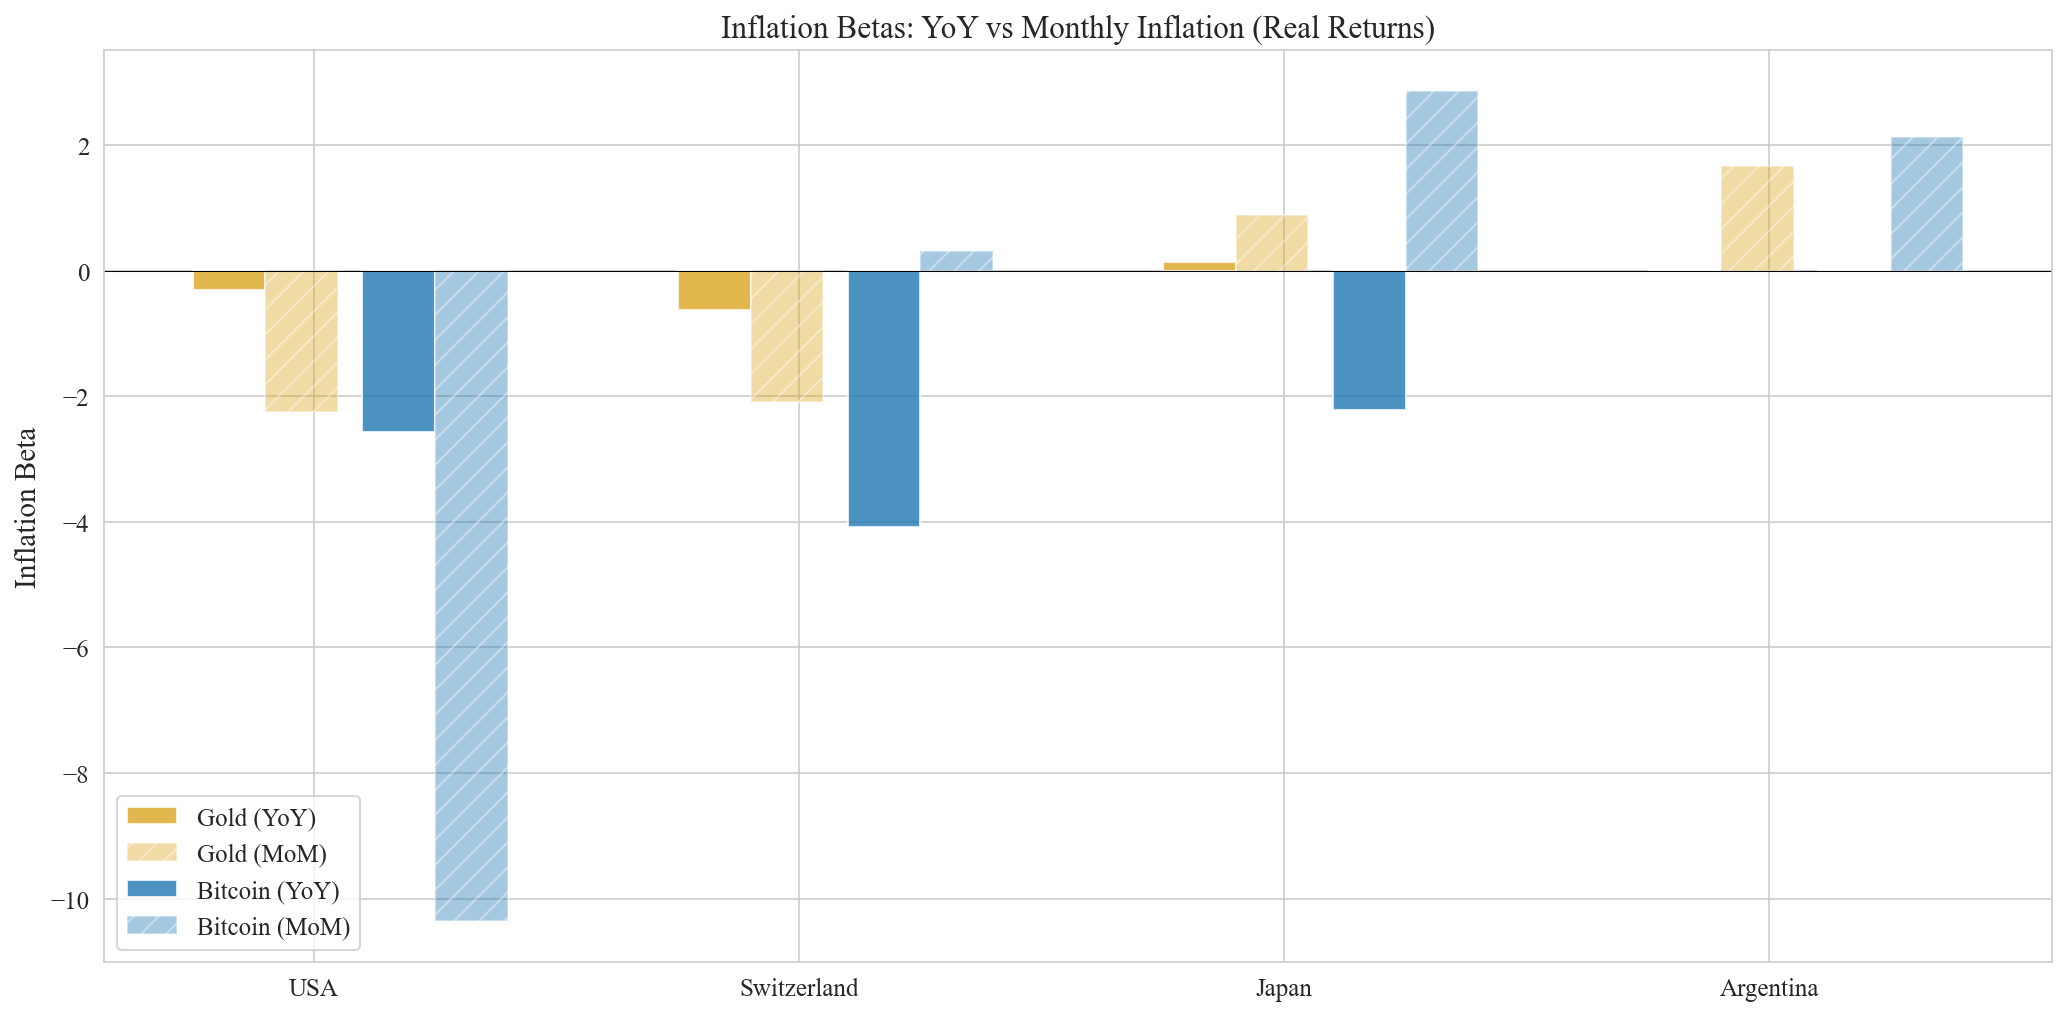

In [44]:
# VISUALIZATION: YoY vs MoM Inflation Betas

fig, ax = plt.subplots(figsize=(14, 7))

countries = ['USA', 'Switzerland', 'Japan', 'Argentina']
x = np.arange(len(countries))
width = 0.15

for i, asset in enumerate(['Gold', 'Bitcoin']):
    yoy_betas = summary_main[summary_main['Asset'] == asset]['Inflation Beta'].values
    mom_betas_vals = summary_monthly[
        summary_monthly['Asset'] == asset]['Inflation Beta (MoM)'].values

    offset = i * (2 * width + 0.05)
    ax.bar(x - width/2 + offset, yoy_betas, width,
           color=GOLD_COLOR if asset == 'Gold' else BTC_COLOR,
           alpha=0.8, label=f'{asset} (YoY)')
    ax.bar(x + width/2 + offset, mom_betas_vals, width,
           color=GOLD_COLOR if asset == 'Gold' else BTC_COLOR,
           alpha=0.4, hatch='//', label=f'{asset} (MoM)')

ax.set_xticks(x + width/2 + 0.025)
ax.set_xticklabels(countries)
ax.set_ylabel('Inflation Beta')
ax.set_title('Inflation Betas: YoY vs Monthly Inflation (Real Returns)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'inflation_betas_yoy_vs_mom.png'),
            dpi=150, bbox_inches='tight')
plt.show()

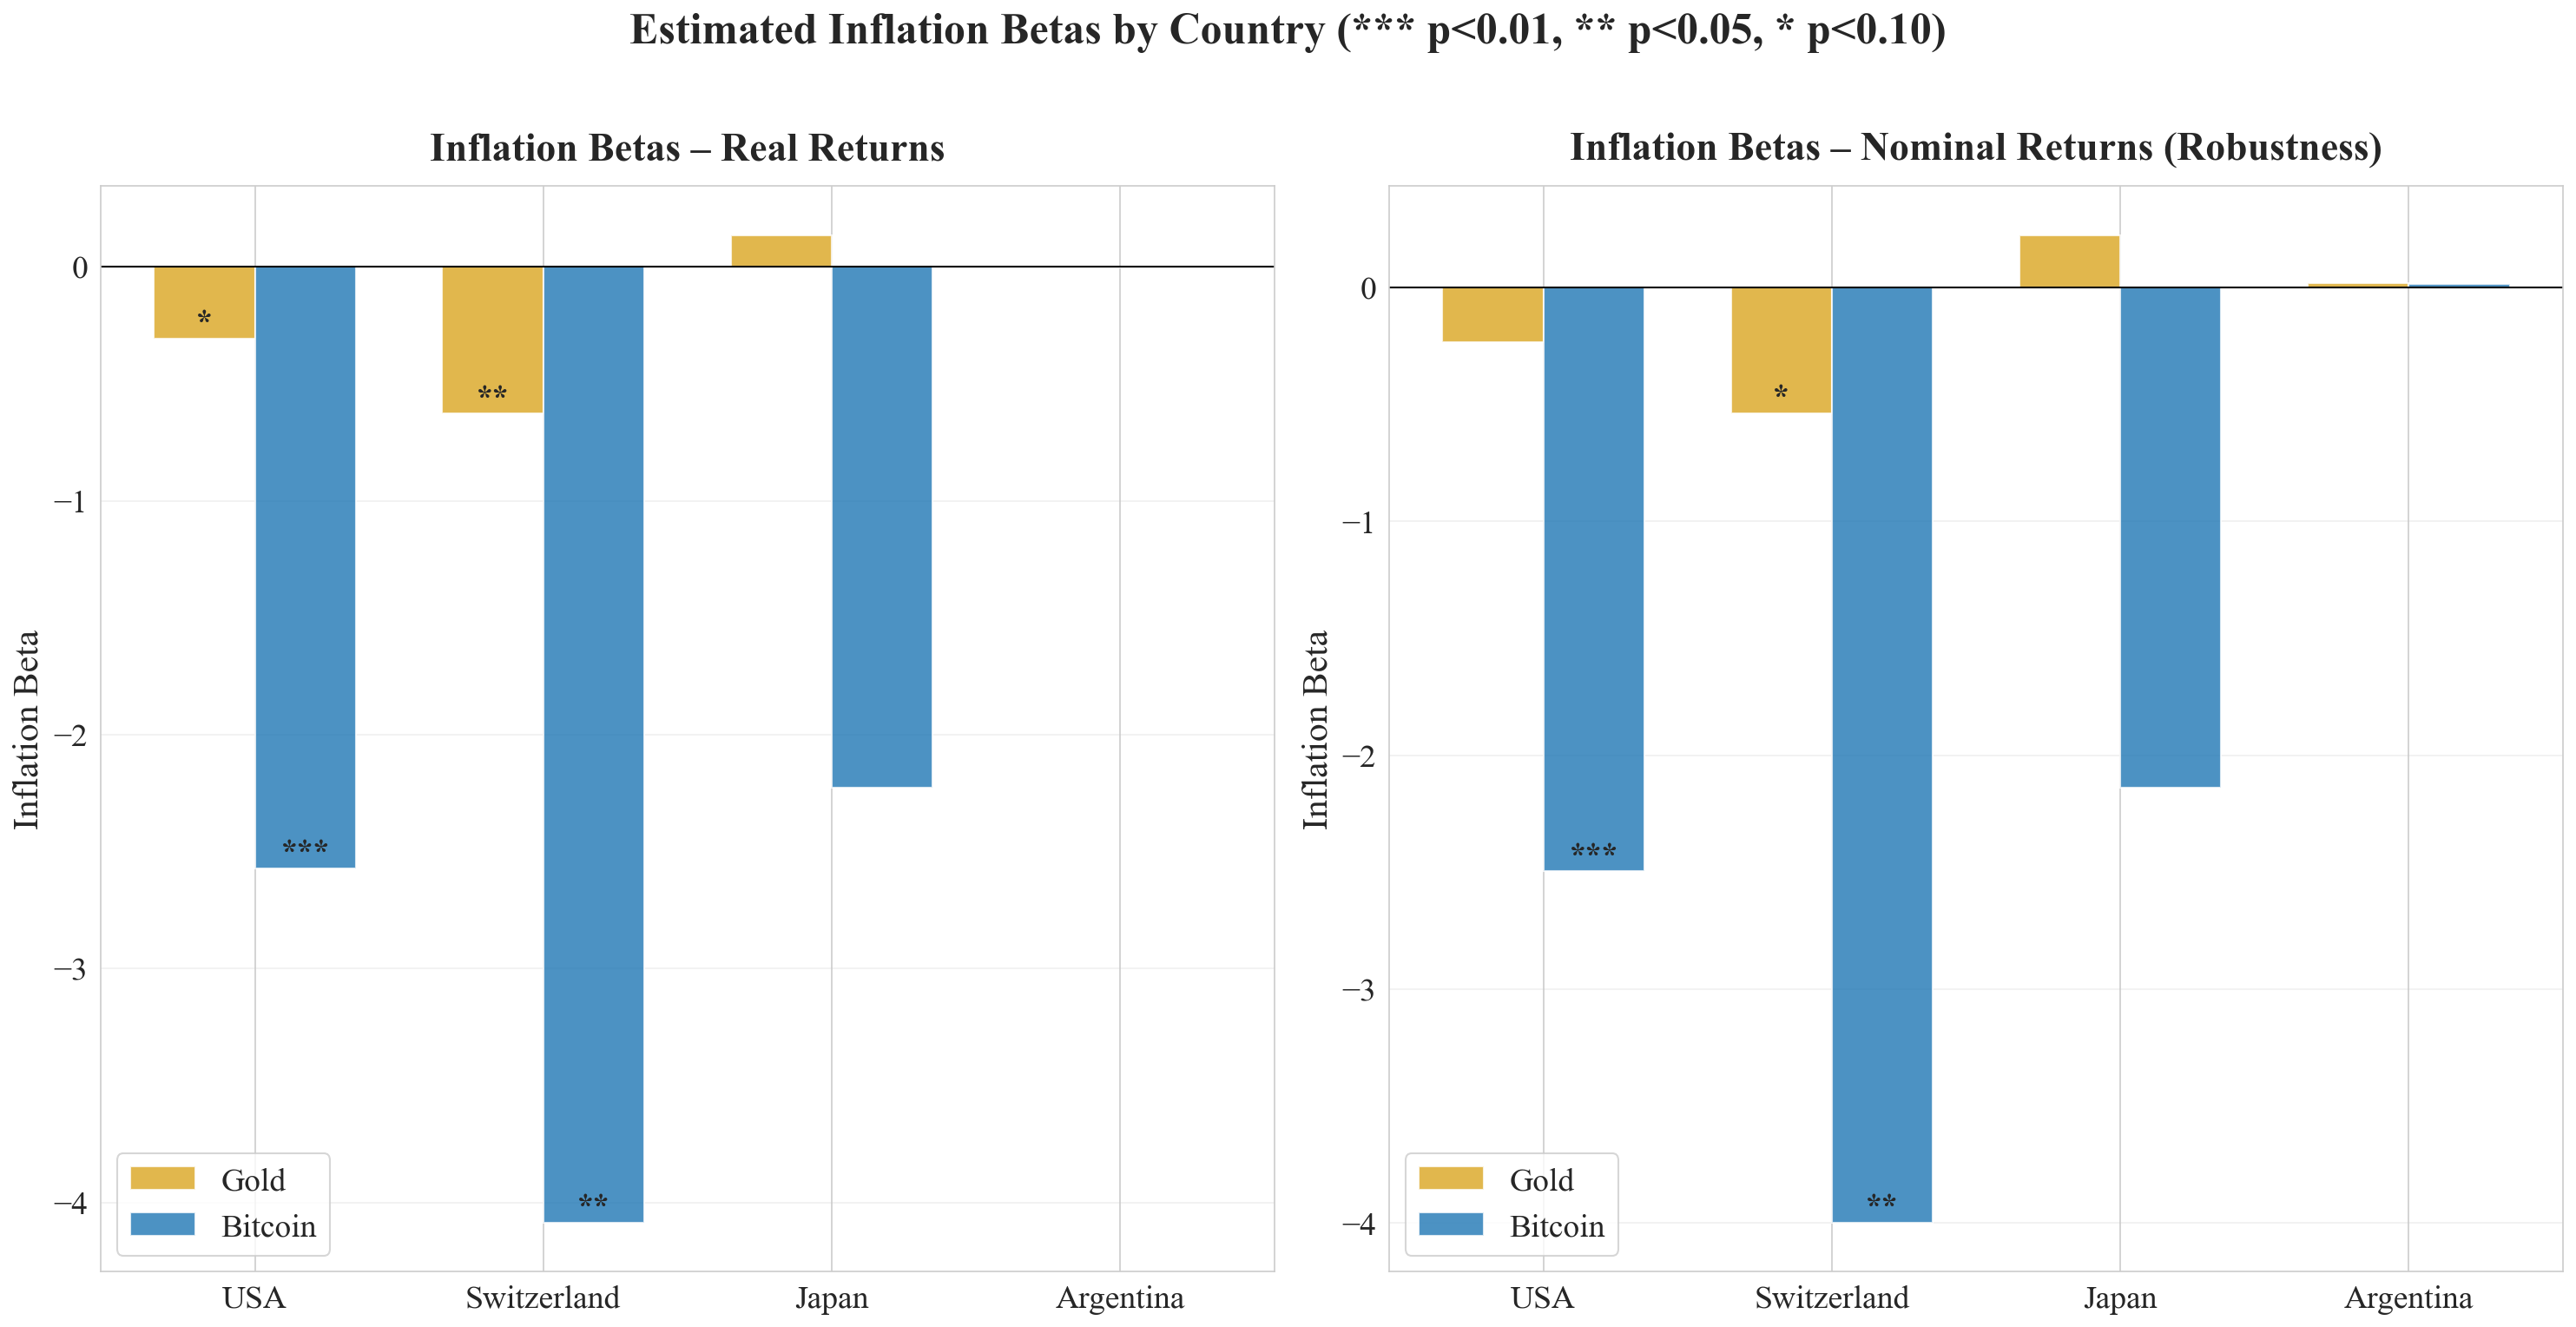

In [45]:
# VISUALIZATION: Inflation Betas by Country

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

countries = ['USA', 'Switzerland', 'Japan', 'Argentina']
x = np.arange(len(countries))
width = 0.35

# Real Returns
ax = axes[0]
gold_betas = summary_main[summary_main['Asset'] == 'Gold']['Inflation Beta'].values
btc_betas = summary_main[summary_main['Asset'] == 'Bitcoin']['Inflation Beta'].values
gold_pvals = summary_main[summary_main['Asset'] == 'Gold']['Beta p-value'].values
btc_pvals = summary_main[summary_main['Asset'] == 'Bitcoin']['Beta p-value'].values

bars1 = ax.bar(x - width/2, gold_betas, width, color=GOLD_COLOR, label='Gold', alpha=0.8)
bars2 = ax.bar(x + width/2, btc_betas, width, color=BTC_COLOR, label='Bitcoin', alpha=0.8)
for i, (gp, bp) in enumerate(zip(gold_pvals, btc_pvals)):
    if gp < 0.01: ax.text(i - width/2, gold_betas[i], '***', ha='center', va='bottom', fontsize=18, fontweight='bold')
    elif gp < 0.05: ax.text(i - width/2, gold_betas[i], '**', ha='center', va='bottom', fontsize=18, fontweight='bold')
    elif gp < 0.10: ax.text(i - width/2, gold_betas[i], '*', ha='center', va='bottom', fontsize=18, fontweight='bold')

    if bp < 0.01: ax.text(i + width/2, btc_betas[i], '***', ha='center', va='bottom', fontsize=18, fontweight='bold')
    elif bp < 0.05: ax.text(i + width/2, btc_betas[i], '**', ha='center', va='bottom', fontsize=18, fontweight='bold')
    elif bp < 0.10: ax.text(i + width/2, btc_betas[i], '*', ha='center', va='bottom', fontsize=18, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(countries, fontsize=18)
ax.set_ylabel('Inflation Beta', fontsize=20)
ax.set_title('Inflation Betas – Real Returns', fontsize=22, fontweight='bold', pad=14)
ax.tick_params(axis='y', which='major', labelsize=18)
ax.axhline(y=0, color='black', linewidth=1.0)
ax.legend(fontsize=18, loc='best')
ax.grid(axis='y', alpha=0.3)

# Nominal Returns
ax = axes[1]
gold_betas_n = summary_robust[summary_robust['Asset'] == 'Gold']['Inflation Beta'].values
btc_betas_n = summary_robust[summary_robust['Asset'] == 'Bitcoin']['Inflation Beta'].values
gold_pvals_n = summary_robust[summary_robust['Asset'] == 'Gold']['Beta p-value'].values
btc_pvals_n = summary_robust[summary_robust['Asset'] == 'Bitcoin']['Beta p-value'].values

bars1 = ax.bar(x - width/2, gold_betas_n, width, color=GOLD_COLOR, label='Gold', alpha=0.8)
bars2 = ax.bar(x + width/2, btc_betas_n, width, color=BTC_COLOR, label='Bitcoin', alpha=0.8)

for i, (gp, bp) in enumerate(zip(gold_pvals_n, btc_pvals_n)):
    if gp < 0.01: ax.text(i - width/2, gold_betas_n[i], '***', ha='center', va='bottom', fontsize=18, fontweight='bold')
    elif gp < 0.05: ax.text(i - width/2, gold_betas_n[i], '**', ha='center', va='bottom', fontsize=18, fontweight='bold')
    elif gp < 0.10: ax.text(i - width/2, gold_betas_n[i], '*', ha='center', va='bottom', fontsize=18, fontweight='bold')

    if bp < 0.01: ax.text(i + width/2, btc_betas_n[i], '***', ha='center', va='bottom', fontsize=18, fontweight='bold')
    elif bp < 0.05: ax.text(i + width/2, btc_betas_n[i], '**', ha='center', va='bottom', fontsize=18, fontweight='bold')
    elif bp < 0.10: ax.text(i + width/2, btc_betas_n[i], '*', ha='center', va='bottom', fontsize=18, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(countries, fontsize=18)
ax.set_ylabel('Inflation Beta', fontsize=20)
ax.set_title('Inflation Betas – Nominal Returns (Robustness)', fontsize=22, fontweight='bold', pad=14)
ax.tick_params(axis='y', which='major', labelsize=18)
ax.axhline(y=0, color='black', linewidth=1.0)
ax.legend(fontsize=18, loc='best')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Estimated Inflation Betas by Country (*** p<0.01, ** p<0.05, * p<0.10)',
             fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'inflation_betas_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

In [46]:
# FULL REGRESSION OUTPUT

print('=' * 80)
print('  FULL REGRESSION OUTPUTS ')
print('=' * 80)

for country, df in [('USA', df_us), ('Switzerland', df_ch), ('Japan', df_jp), ('Argentina', df_ar)]:
    for asset, ret_real, ret_nom in [('Gold', 'gold_real_ret', 'gold_ret'), 
                                      ('Bitcoin', 'btc_real_ret', 'btc_ret')]:

        # Real Return model
        reg_data = df[[ret_real, 'cpi_yoy', 'policy_rate']].dropna()
        Y = reg_data[ret_real]
        X = sm.add_constant(reg_data[['cpi_yoy', 'policy_rate']])
        model_real = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

        print(f'\n\n{"="*70}')
        print(f'  {country} – {asset} (REAL Return, HAC SE)')
        print(f'{"="*70}')
        print(model_real.summary())

        # Nominal Return model
        reg_data = df[[ret_nom, 'cpi_yoy', 'policy_rate']].dropna()
        Y = reg_data[ret_nom]
        X = sm.add_constant(reg_data[['cpi_yoy', 'policy_rate']])
        model_nom = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

        print(f'\n\n{"="*70}')
        print(f'  {country} – {asset} (NOMINAL Return, HAC SE)')
        print(f'{"="*70}')
        print(model_nom.summary())

  FULL REGRESSION OUTPUTS 


  USA – Gold (REAL Return, HAC SE)
                            OLS Regression Results                            
Dep. Variable:          gold_real_ret   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     5.678
Date:                Tue, 19 May 2026   Prob (F-statistic):            0.00444
Time:                        22:13:02   Log-Likelihood:                -332.43
No. Observations:                 119   AIC:                             670.9
Df Residuals:                     116   BIC:                             679.2
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

In [47]:
# SAVE REGRESSION TABLES AS CSV

TABS = 'tables'
os.makedirs(TABS, exist_ok=True)

summary_main.to_csv(os.path.join(TABS, 'regression_main_real.csv'), index=False)

summary_robust.to_csv(os.path.join(TABS, 'regression_robustness_nominal.csv'), index=False)

comparison.to_csv(os.path.join(TABS, 'regression_comparison.csv'), index=False)

summary_monthly.to_csv(os.path.join(TABS, 'regression_robustness_monthly.csv'), index=False)

comp_horizon.to_csv(os.path.join(TABS, 'regression_comparison_horizon.csv'), index=False)

for name, df in [('usa', df_us), ('switzerland', df_ch), ('japan', df_jp), ('argentina', df_ar)]:
    summary_stats(df).to_csv(os.path.join(TABS, f'summary_stats_{name}.csv'), index=False)

print('Saved:')
for f in os.listdir(TABS):
    print(f'  {TABS}/{f}')

Saved:
  tables/summary_stats_usa.csv
  tables/summary_stats_switzerland.csv
  tables/.DS_Store
  tables/regression_comparison.csv
  tables/regression_main_real.csv
  tables/regression_robustness_monthly.csv
  tables/.ipynb_checkpoints
  tables/regression_robustness_nominal.csv
  tables/summary_stats_argentina.csv
  tables/summary_stats_japan.csv
  tables/regression_comparison_horizon.csv


  NOTE: Switzerland – Gold in Pre-COVID (2016–2019): dropped ['policy_rate'] (zero variance)
  NOTE: Switzerland – Bitcoin in Pre-COVID (2016–2019): dropped ['policy_rate'] (zero variance)
  NOTE: Japan – Gold in Pre-COVID (2016–2019): dropped ['policy_rate'] (zero variance)
  NOTE: Japan – Bitcoin in Pre-COVID (2016–2019): dropped ['policy_rate'] (zero variance)
  NOTE: Japan – Gold in COVID & Inflation (2020–2022): dropped ['policy_rate'] (zero variance)
  NOTE: Japan – Bitcoin in COVID & Inflation (2020–2022): dropped ['policy_rate'] (zero variance)
  SUB-PERIOD REGRESSIONS – Real Returns (HAC Standard Errors)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pre-COVID (2016–2019)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

──────────────────────────────────────────────────────────────────────
  USA – Gold (Real Return)
──────────────────────────────────────────────────────────────────────
  Observations:   47


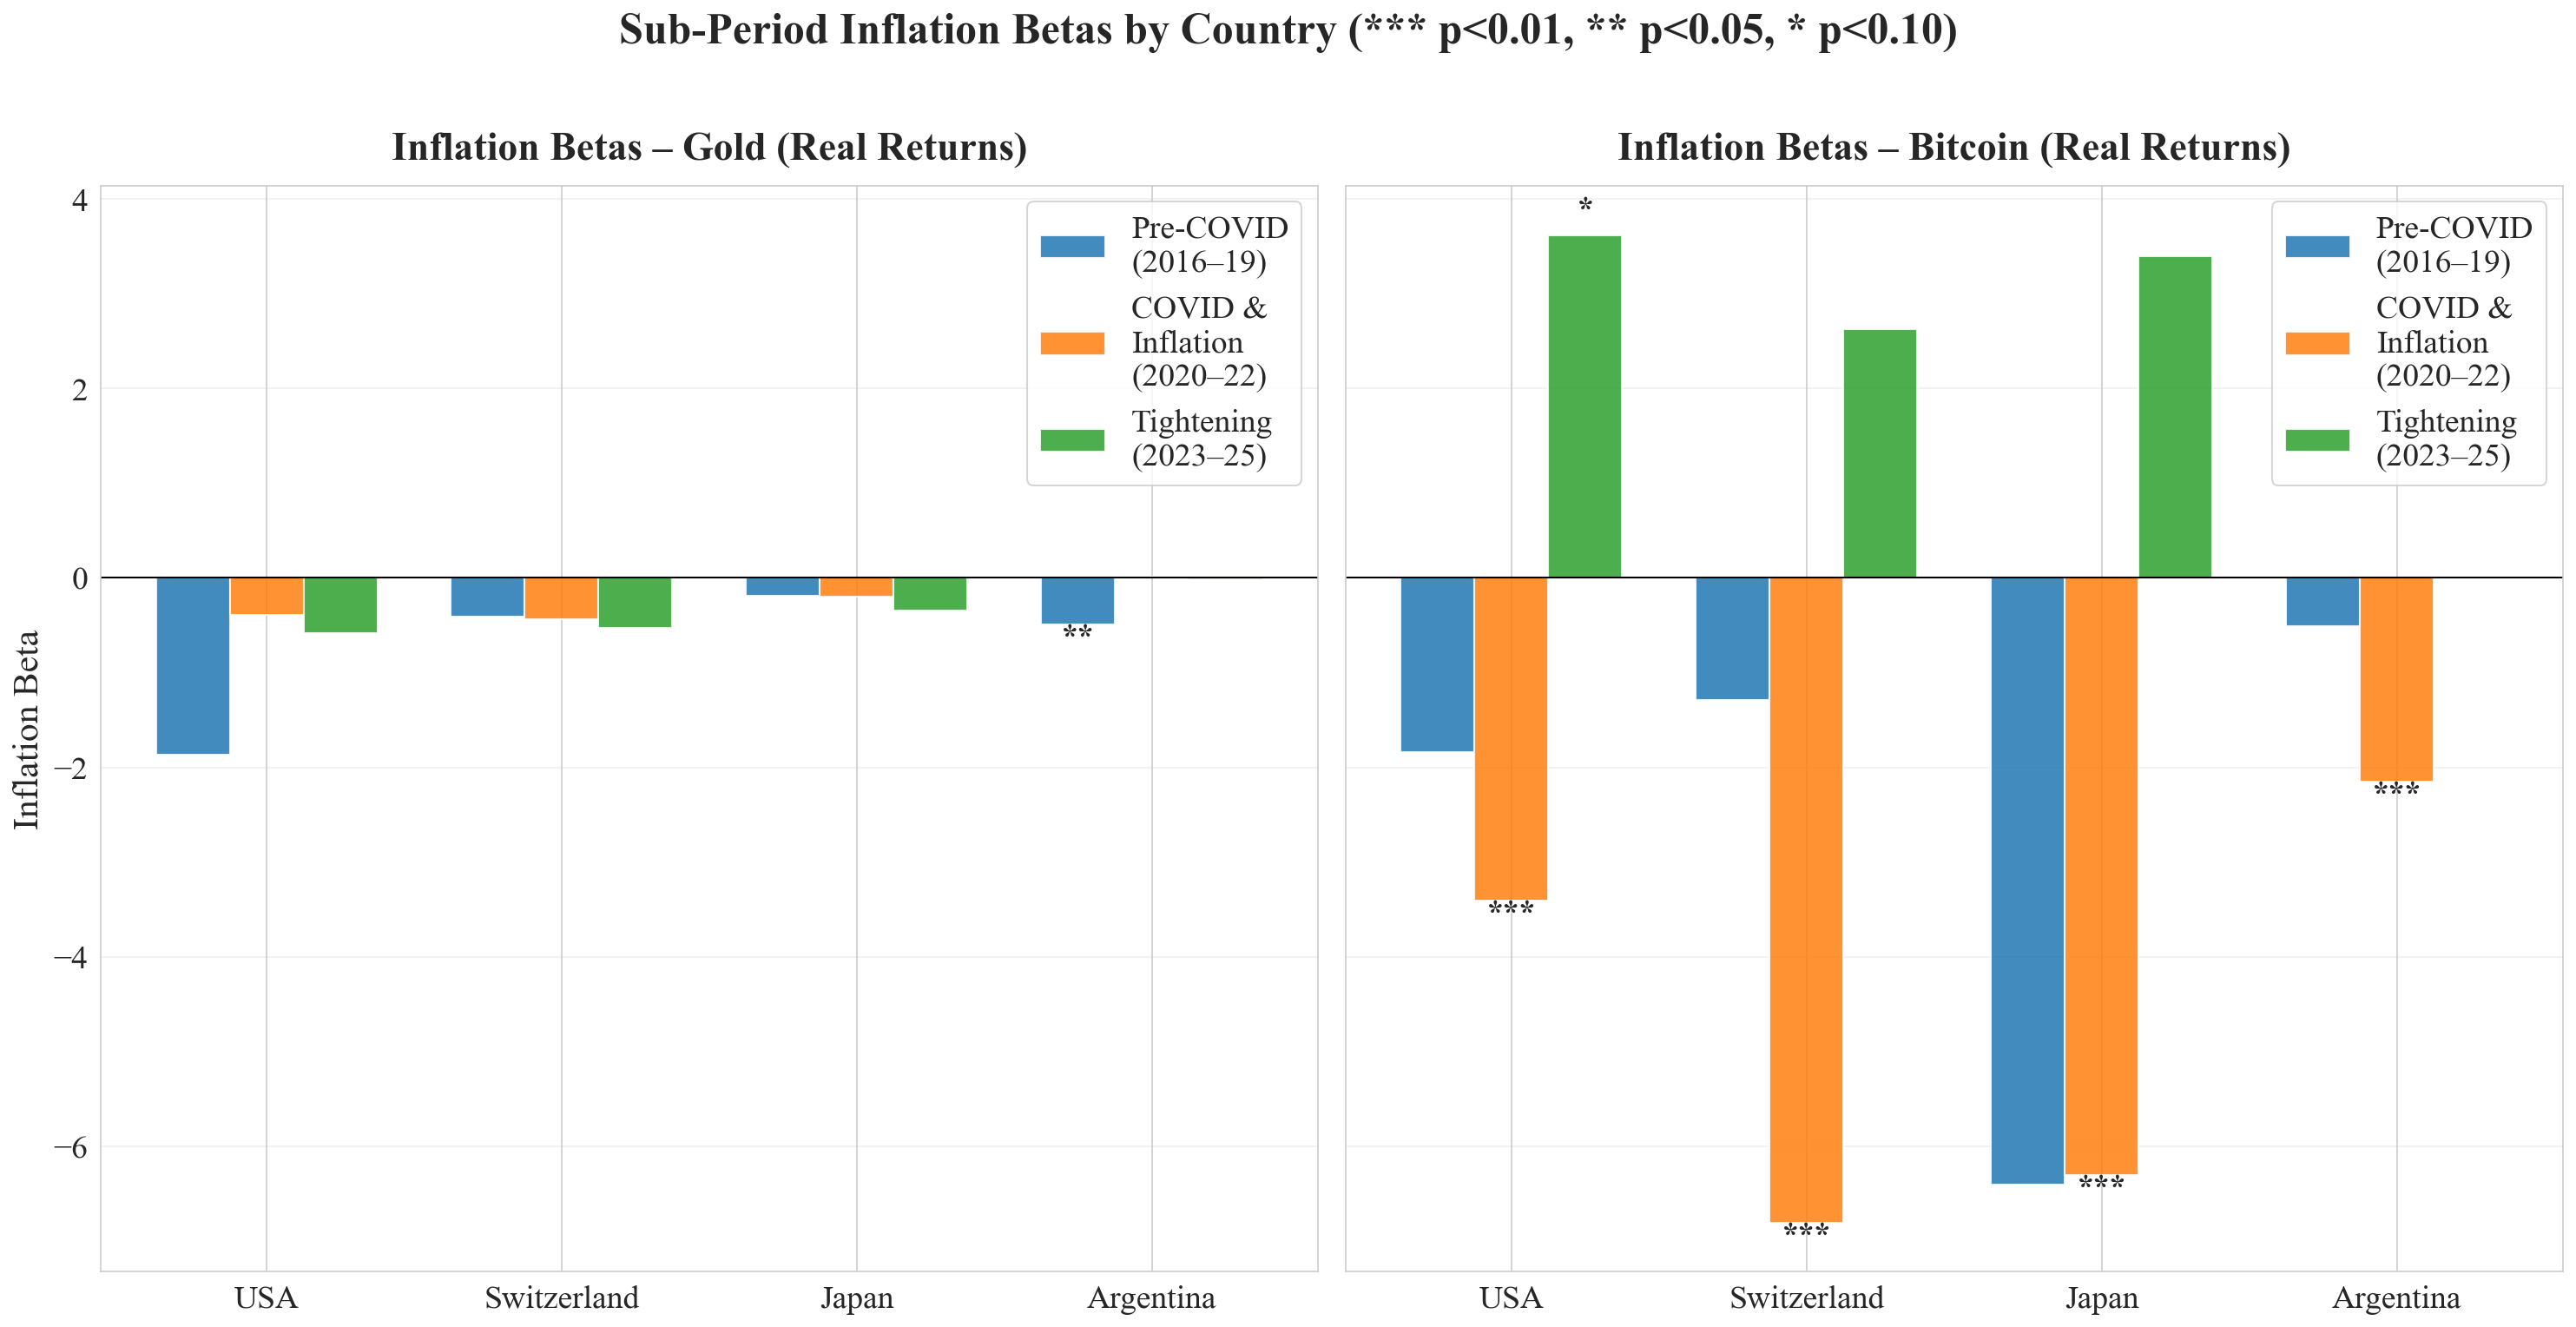


Sub-period analysis complete.
Figure saved to figures/sub_period_betas.png


In [48]:
#  SUB-PERIOD REGRESSIONS – Inflation Betas by Macroeconomic Phase

# Define sub-periods
sub_periods = {
    'Pre-COVID (2016–2019)': ('2016-01-31', '2019-12-31'),
    'COVID & Inflation (2020–2022)': ('2020-01-31', '2022-12-31'),
    'Tightening (2023–2025)': ('2023-01-31', '2025-12-31')
}
results_sub = []
 
for period_name, (start, end) in sub_periods.items():
    start_date = pd.Timestamp(start)
    end_date = pd.Timestamp(end)
    
    for country, df in [('USA', df_us), ('Switzerland', df_ch),
                        ('Japan', df_jp), ('Argentina', df_ar)]:
        
        mask = (df['date'] >= start_date) & (df['date'] <= end_date)
        df_sub = df[mask].copy()
        
        for asset, ret_col in [('Gold', 'gold_real_ret'),
                                ('Bitcoin', 'btc_real_ret')]:
            
            reg_data = df_sub[[ret_col, 'cpi_yoy', 'policy_rate']].dropna()
            
            if len(reg_data) < 10:
                print(f'  SKIPPED: {country} – {asset} in {period_name} '
                      f'(only {len(reg_data)} obs)')
                continue
            
            Y = reg_data[ret_col]
            
            regressors = ['cpi_yoy', 'policy_rate']
            dropped = [r for r in regressors if reg_data[r].std() <= 1e-10]
            regressors = [r for r in regressors if r not in dropped]
            
            if dropped:
                print(f'  NOTE: {country} – {asset} in {period_name}: '
                      f'dropped {dropped} (zero variance)')
            
            if not regressors:
                print(f'  SKIPPED: {country} – {asset} in {period_name} '
                      f'(no regressor variation)')
                continue
            
            X = sm.add_constant(reg_data[regressors],
                                has_constant='add')
            
            model_hac = sm.OLS(Y, X).fit(
                cov_type='HAC', cov_kwds={'maxlags': 4}
            )
            
            model = sm.OLS(Y, X).fit()
            resid = model.resid
            
            bp_stat, bp_pval, _, _ = het_breuschpagan(resid, X)
            dw = durbin_watson(resid)
            jb_stat, jb_pval = jarque_bera(resid)[:2]
            
            results_sub.append({
                'Period': period_name,
                'Country': country,
                'Asset': asset,
                'Obs': int(model_hac.nobs),
                'Inflation Beta': model_hac.params.get('cpi_yoy', np.nan),
                'Beta p-value': model_hac.pvalues.get('cpi_yoy', np.nan),
                'Policy Rate Coef': model_hac.params.get('policy_rate', np.nan),
                'Rate p-value': model_hac.pvalues.get('policy_rate', np.nan),
                'Constant': model_hac.params.get('const', np.nan),
                'R-squared': model.rsquared,
                'Durbin-Watson': dw,
                'BP p-value': bp_pval,
                'JB p-value': jb_pval,
                'Regressors': regressors
            })
 
summary_sub = pd.DataFrame(results_sub)
 
# Print detailed results per period
print('=' * 80)
print('  SUB-PERIOD REGRESSIONS – Real Returns (HAC Standard Errors)')
print('=' * 80)
 
for period_name in sub_periods.keys():
    period_data = summary_sub[summary_sub['Period'] == period_name]
    
    print(f'\n\n{"━" * 80}')
    print(f'  {period_name}')
    print(f'{"━" * 80}')
    
    for _, row in period_data.iterrows():
        sig = ''
        if pd.notna(row['Beta p-value']):
            if row['Beta p-value'] < 0.01:
                sig = '***'
            elif row['Beta p-value'] < 0.05:
                sig = '**'
            elif row['Beta p-value'] < 0.10:
                sig = '*'
        
        print(f'\n{"─" * 70}')
        print(f'  {row["Country"]} – {row["Asset"]} (Real Return)')
        print(f'{"─" * 70}')
        print(f'  Observations:   {row["Obs"]:.0f}')
        print(f'  R-squared:      {row["R-squared"]:.4f}')
        print(f'')
        if pd.notna(row['Inflation Beta']):
            print(f'  Inflation Beta: {row["Inflation Beta"]:.4f} '
                  f'(p = {row["Beta p-value"]:.4f}) {sig}')
        else:
            print(f'  Inflation Beta: n/a (dropped – zero variance)')
        if pd.notna(row['Policy Rate Coef']):
            print(f'  Policy Rate:    {row["Policy Rate Coef"]:.4f} '
                  f'(p = {row["Rate p-value"]:.4f})')
        else:
            print(f'  Policy Rate:    n/a (dropped – zero variance)')
        print(f'  Constant:       {row["Constant"]:.4f}')
        print(f'')
        print(f'  Durbin-Watson:  {row["Durbin-Watson"]:.3f}')
        bp_flag = '** heteroskedasticity' if row['BP p-value'] < 0.05 else '(ok)'
        jb_flag = '** non-normal residuals' if row['JB p-value'] < 0.05 else '(ok)'
        print(f'  Breusch-Pagan p: {row["BP p-value"]:.4f} {bp_flag}')
        print(f'  Jarque-Bera p:   {row["JB p-value"]:.4f} {jb_flag}')
 
print('\n\n')
print('=' * 80)
print('  SUMMARY: Inflation Betas by Sub-Period')
print('=' * 80)
 
def sig_star(p):
    if pd.isna(p): return ''
    if p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.10: return '*'
    else: return ''
 
summary_display = summary_sub[['Period', 'Country', 'Asset', 'Obs',
                                'Inflation Beta', 'Beta p-value',
                                'R-squared']].copy()
summary_display['Sig'] = summary_display['Beta p-value'].apply(sig_star)
 
print()
print(summary_display.to_string(index=False, float_format='%.4f'))
print('\nSignificance: *** p < 0.01, ** p < 0.05, * p < 0.10')
 
 
# Comparison: Full Sample vs Sub-Periods (per Country × Asset)
print('\n\n')
print('=' * 80)
print('  COMPARISON: Full Sample vs Sub-Period Inflation Betas')
print('=' * 80)
 
full_betas = pd.DataFrame(results_main)[['Country', 'Asset', 'Inflation Beta',
                                          'Beta p-value']]
full_betas.columns = ['Country', 'Asset', 'Full Sample Beta', 'Full p-value']
 
for country in ['USA', 'Switzerland', 'Japan', 'Argentina']:
    print(f'\n{"─" * 70}')
    print(f'  {country}')
    print(f'{"─" * 70}')
    
    for asset in ['Gold', 'Bitcoin']:
        full_row = full_betas[(full_betas['Country'] == country) & 
                              (full_betas['Asset'] == asset)]
        if full_row.empty:
            continue
        
        fb = full_row.iloc[0]['Full Sample Beta']
        fp = full_row.iloc[0]['Full p-value']
        
        print(f'\n  {asset}:')
        print(f'    Full Sample:            β = {fb:>8.4f}  '
              f'(p = {fp:.4f}) {sig_star(fp)}')
        
        for period_name in sub_periods.keys():
            sub_row = summary_sub[(summary_sub['Period'] == period_name) &
                                  (summary_sub['Country'] == country) &
                                  (summary_sub['Asset'] == asset)]
            if not sub_row.empty:
                sb = sub_row.iloc[0]['Inflation Beta']
                sp = sub_row.iloc[0]['Beta p-value']
                n = sub_row.iloc[0]['Obs']
                # Shorten period name for alignment
                short_name = period_name.split('(')[0].strip()
                print(f'    {short_name:<24}β = {sb:>8.4f}  '
                      f'(p = {sp:.4f}) {sig_star(sp)}  [n={n:.0f}]')
 
 
# Visualization: Inflation Betas across sub-periods
fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

period_labels = ['Pre-COVID\n(2016–19)', 'COVID &\nInflation\n(2020–22)',
                 'Tightening\n(2023–25)']
countries = ['USA', 'Switzerland', 'Japan', 'Argentina']
x = np.arange(len(countries))
width = 0.25

for idx, (asset, ax) in enumerate(zip(['Gold', 'Bitcoin'], axes)):
    for i, (period_name, label) in enumerate(zip(sub_periods.keys(),
                                                  period_labels)):
        betas = []
        sigs = []
        for country in countries:
            row = summary_sub[(summary_sub['Period'] == period_name) &
                              (summary_sub['Country'] == country) &
                              (summary_sub['Asset'] == asset)]
            if not row.empty and pd.notna(row.iloc[0]['Inflation Beta']):
                betas.append(row.iloc[0]['Inflation Beta'])
                sigs.append(row.iloc[0]['Beta p-value'])
            else:
                betas.append(0)
                sigs.append(1)
        
        bars = ax.bar(x + (i - 1) * width, betas, width, label=label,
                      alpha=0.85)
        
        for j, (bar, p) in enumerate(zip(bars, sigs)):
            star = sig_star(p)
            if star:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.1 if bar.get_height() >= 0
                        else bar.get_height() - 0.3,
                        star, ha='center', va='bottom', fontsize=18,
                        fontweight='bold')
    
    ax.set_title(f'Inflation Betas – {asset} (Real Returns)',
                 fontsize=22, fontweight='bold', pad=14)
    ax.set_xticks(x)
    ax.set_xticklabels(countries, fontsize=18)
    ax.set_ylabel('Inflation Beta' if idx == 0 else '', fontsize=20)
    ax.tick_params(axis='y', which='major', labelsize=18)
    ax.axhline(y=0, color='black', linewidth=1.0, linestyle='-')
    ax.legend(fontsize=18, loc='best')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Sub-Period Inflation Betas by Country (*** p<0.01, ** p<0.05, * p<0.10)',
             fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'sub_period_betas.png'), dpi=300,
            bbox_inches='tight')
plt.show()

print('\nSub-period analysis complete.')
print(f'Figure saved to {FIGS}/sub_period_betas.png')